# Scraping NikeRunClub App Reviews

Nama : Dewi Maharani

NRP : 5026221046

Kelas : PBA (B)

# SET UP

In [56]:
# Install libraries
!pip install google_play_scraper
!pip install textblob
!pip install emoji
!pip install seaborn

In [57]:
# Import Libraries
# Standard libraries
import os
import time
import datetime
import re
from pathlib import Path
from PIL import Image

# Data handling and visualization libraries
import pandas as pd
import numpy as np
import nltk
import string
import emoji
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

# Machine learning and NLP libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS

# Google Play Scraper
from google_play_scraper import app, Sort, reviews, reviews_all

# Utility Libraries
from copy import deepcopy
from IPython.display import clear_output

# Matplotlib & Seaborn Configuration
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_style("whitegrid")  # Menggunakan seaborn style
plt.rcParams["figure.figsize"] = (15, 10)

print("Libraries imported successfully.")


Libraries imported successfully.


# Scraping

- Nama aplikasi yang akan di-scraping review-nya pada Google Play adalah Nike Run Club - Running Coach

- Link App Android dari Nike Run Club pada Google Play : https://play.google.com/store/apps/details?id=com.nike.plusgps&hl=en

- ID aplikasi Nike Run Club adalah com.nike.plusgps

- Pada tanggal 16 Maret 2025, jumlah review aplikasi pada Google Play adalah 1.08 juta


In [58]:
# Mengambil semua review dari aplikasi Nike Run Club
nike_reviews = reviews_all(
    'com.nike.plusgps',  # ID aplikasi Nike Run Club
    sleep_milliseconds=0,  # Tidak ada jeda antar request
    lang='en',  # Bahasa Inggris
    sort=Sort.NEWEST,  # Urutkan berdasarkan yang terbaru
)

In [59]:
# Simpan hasil scraping ke dalam DataFrame
df_nike_reviews = pd.DataFrame(np.array(nike_reviews), columns=['content'])
df_nike_reviews = df_nike_reviews.join(pd.DataFrame(df_nike_reviews.pop('content').tolist()))

In [60]:
df_nike_reviews

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,592a1f48-372b-4911-8815-667875bb98e0,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,4.63.1,2025-03-25 10:31:04,None,NaT,4.63.1
1,2745b453-1da6-4a4c-a496-2274c9ffd7fe,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,The Nike Run Club is the best. The App tracks ...,5,0,4.64.0,2025-03-25 00:54:56,None,NaT,4.64.0
2,5fb53101-276d-4f20-9e34-88bb77a101ac,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,This app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,None,NaT,4.64.0
3,c283791d-cf84-4d75-ad3d-d4b1494d96fe,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,None,NaT,4.64.0
4,71e42c48-ec45-4157-9729-d4253c007d46,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,easy to use beginner friendly im not a bot,5,0,4.64.0,2025-03-24 18:01:49,None,NaT,4.64.0
...,...,...,...,...,...,...,...,...,...,...,...
126513,693ad724-e2d7-4aa9-9aa6-dbde8180286b,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Great for anyone who starts running or training!!,5,0,None,2012-06-21 23:31:12,None,NaT,None
126514,a7cc2172-a575-4f55-b77b-3bbe386ba0e1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,This is soooo much better then the Iphone app!...,5,1,None,2012-06-21 23:16:50,None,NaT,None
126515,e9a1307d-8cdd-4b20-82ee-689148e9d9c2,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,None,NaT,1.0.0
126516,1cbaec91-d507-4ccb-ab41-2204352b39ce,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Excellent App!!!!!!,5,2,1.0.0,2012-06-21 23:03:17,None,NaT,1.0.0


In [61]:
# Menampilkan jumlah baris dan kolom DataFrame
print(f"Jumlah data yang telah di-scraping: {df_nike_reviews.shape[0]}")

Jumlah data yang telah di-scraping: 126518


In [62]:
# Simpan DataFrame ke dalam file CSV di direktori saat ini
file_path = 'nike_run_club_reviews.csv'

# Simpan DataFrame ke dalam file CSV
df_nike_reviews.to_csv(file_path, index=False, encoding="utf-8")

print(f"DataFrame telah disimpan ke {file_path}")

DataFrame telah disimpan ke nike_run_club_reviews.csv


# Cleaning Dataframe


In [63]:
!pip install langdetect


In [64]:
!pip install --upgrade pip

In [65]:
!pip install --no-cache-dir langdetect

<ipython-input-66-f221051e7e81>:8: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_nike_reviews = pd.read_csv('nike_run_club_reviews.csv')


Distribusi Skor Review:
score
5    74057
4    20738
1    15249
3     9350
2     7124
Name: count, dtype: int64


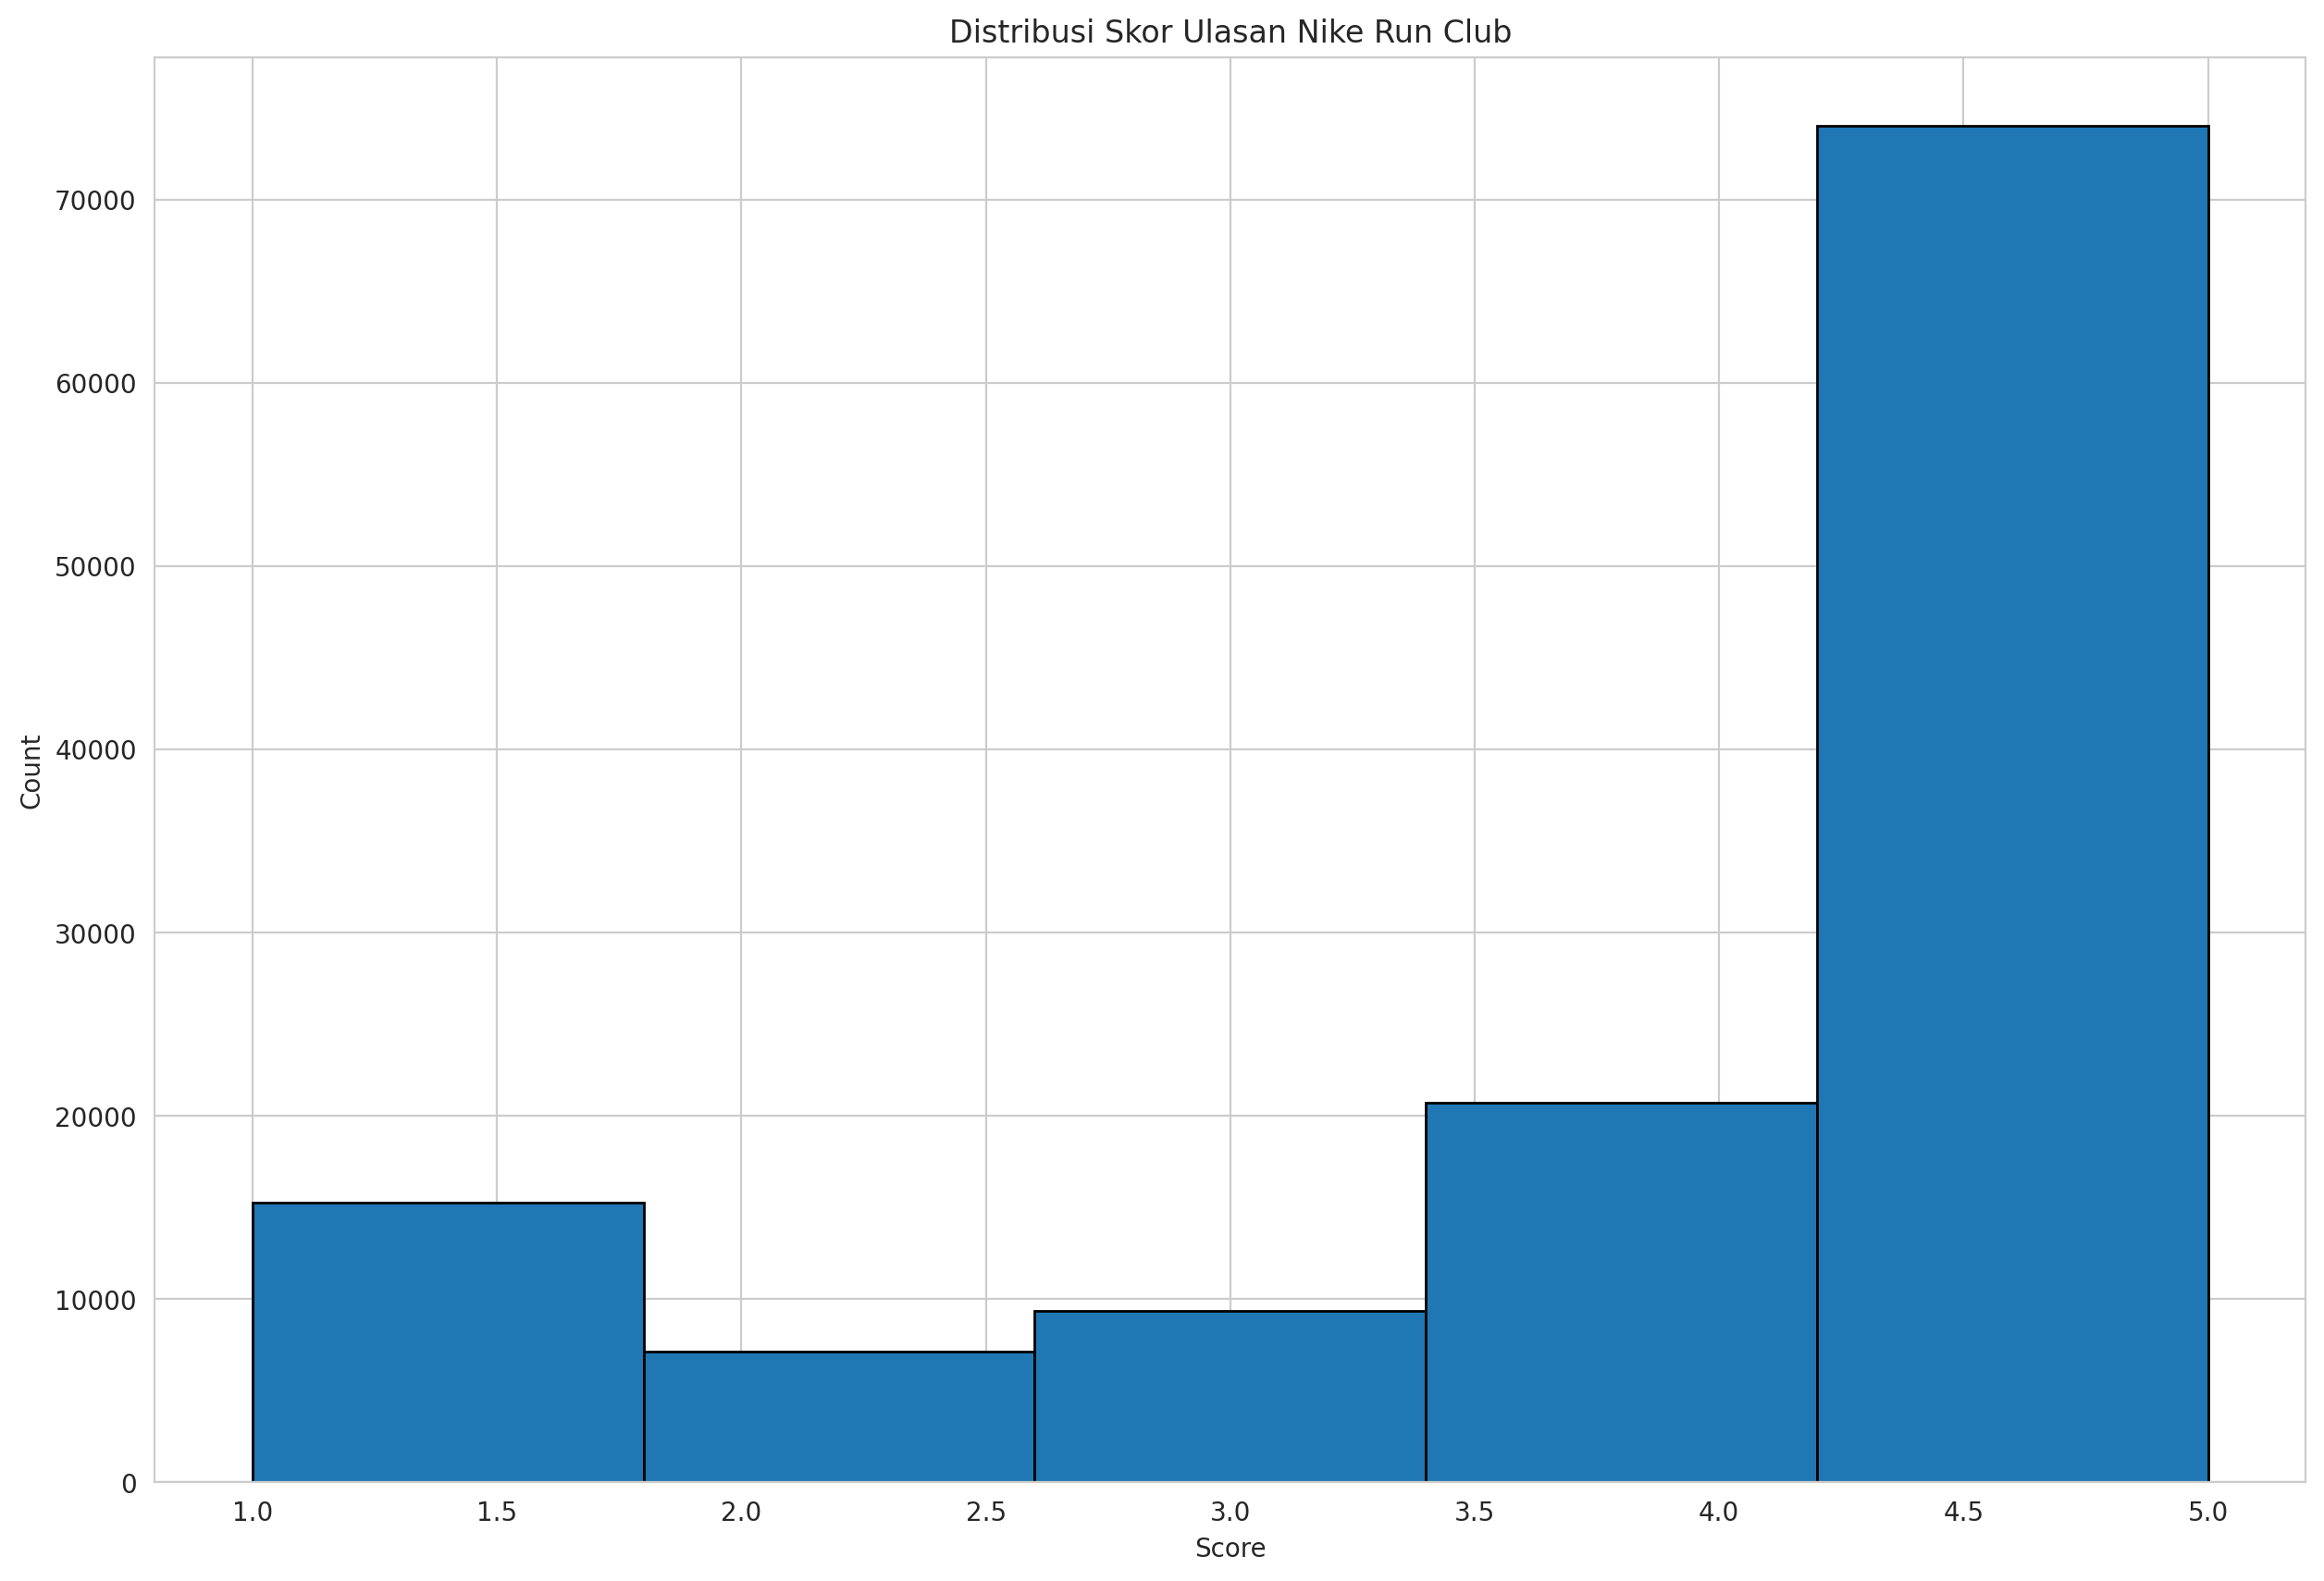


Jumlah bahasa yang terdeteksi:
language
en         103711
af           3436
no           2718
so           2105
ro           1538
it           1452
sl           1234
tl           1233
fr           1156
ca           1028
de            726
id            678
es            660
sw            555
unknown       506
nl            466
pt            394
et            365
cy            354
da            353
pl            317
sv            254
sq            195
fi            185
hu            110
hr            108
tr             90
ar             84
ru             84
cs             72
th             54
vi             52
sk             48
ko             39
lt             34
zh-cn          19
lv             18
fa             13
he             12
ja             11
hi             10
bg              9
uk              8
ur              7
el              4
zh-tw           4
mr              2
kn              2
mk              2
ta              2
ne              1
Name: count, dtype: int64

Data jumlah ba

In [66]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect, LangDetectException
from collections import Counter

# Baca ulang DataFrame dari CSV (pastikan file ada di direktori yang benar)
df_nike_reviews = pd.read_csv('nike_run_club_reviews.csv')

# Tambahkan kolom ID Incremental
df_nike_reviews['id'] = range(1, len(df_nike_reviews) + 1)

# Hapus kolom yang tidak dibutuhkan (cek apakah kolom ini ada sebelum menghapus)
columns_to_drop = ["reviewId", "userName", "userImage", "replyContent", "repliedAt"]
df_nike_reviews = df_nike_reviews.drop(columns=[col for col in columns_to_drop if col in df_nike_reviews.columns])

# Menampilkan jumlah skor review
print("Distribusi Skor Review:")
print(df_nike_reviews['score'].value_counts())

# Plot histogram distribusi skor
plt.hist(df_nike_reviews['score'], bins=5, edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Count')
plt.title('Distribusi Skor Ulasan Nike Run Club')
plt.show()

# Fungsi untuk mendeteksi bahasa
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

# Perbaikan: Pastikan kolom 'content' tidak memiliki NaN dan dikonversi ke string
df_nike_reviews['content'] = df_nike_reviews['content'].astype(str).fillna("")

# Tambahkan kolom bahasa yang terdeteksi
df_nike_reviews['language'] = df_nike_reviews['content'].apply(detect_language)

# Tampilkan jumlah bahasa yang terdeteksi sebelum difilter
print("\nJumlah bahasa yang terdeteksi:")
print(df_nike_reviews['language'].value_counts())

# Filter hanya review berbahasa Inggris
df_nike_reviews = df_nike_reviews[df_nike_reviews['language'] == 'en']

# Hitung jumlah masing-masing bahasa yang terdeteksi
language_counts = Counter(df_nike_reviews['language'])

# Buat DataFrame dari hasil perhitungan bahasa
language_df = pd.DataFrame.from_dict(language_counts, orient='index', columns=['count'])
language_df.index.name = 'language'
language_df = language_df.sort_values(by='count', ascending=False).reset_index()

# Tampilkan hasil jumlah bahasa yang terdeteksi
print("\nData jumlah bahasa yang tersaring:")
print(language_df)

# Tampilkan informasi DataFrame setelah filtering
print("\nInformasi DataFrame setelah filtering:")
df_nike_reviews.info()


In [67]:
# Filter hanya review berbahasa Inggris
df_nike_reviews = df_nike_reviews[df_nike_reviews['language'] == 'en']

# Tampilkan informasi DataFrame setelah filtering
df_nike_reviews.info()

# Hapus kolom 'language' setelah filtering
df_nike_reviews = df_nike_reviews.drop(columns=["language"])


<class 'pandas.core.frame.DataFrame'>
Index: 103711 entries, 1 to 126517
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   content               103711 non-null  object
 1   score                 103711 non-null  int64 
 2   thumbsUpCount         103711 non-null  int64 
 3   reviewCreatedVersion  96143 non-null   object
 4   at                    103711 non-null  object
 5   appVersion            96143 non-null   object
 6   id                    103711 non-null  int64 
 7   language              103711 non-null  object
dtypes: int64(3), object(5)
memory usage: 7.1+ MB


In [68]:
df_nike_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103711 entries, 1 to 126517
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   content               103711 non-null  object
 1   score                 103711 non-null  int64 
 2   thumbsUpCount         103711 non-null  int64 
 3   reviewCreatedVersion  96143 non-null   object
 4   at                    103711 non-null  object
 5   appVersion            96143 non-null   object
 6   id                    103711 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 6.3+ MB


# Polaritas Sentimen sebelum Text Preprocessing

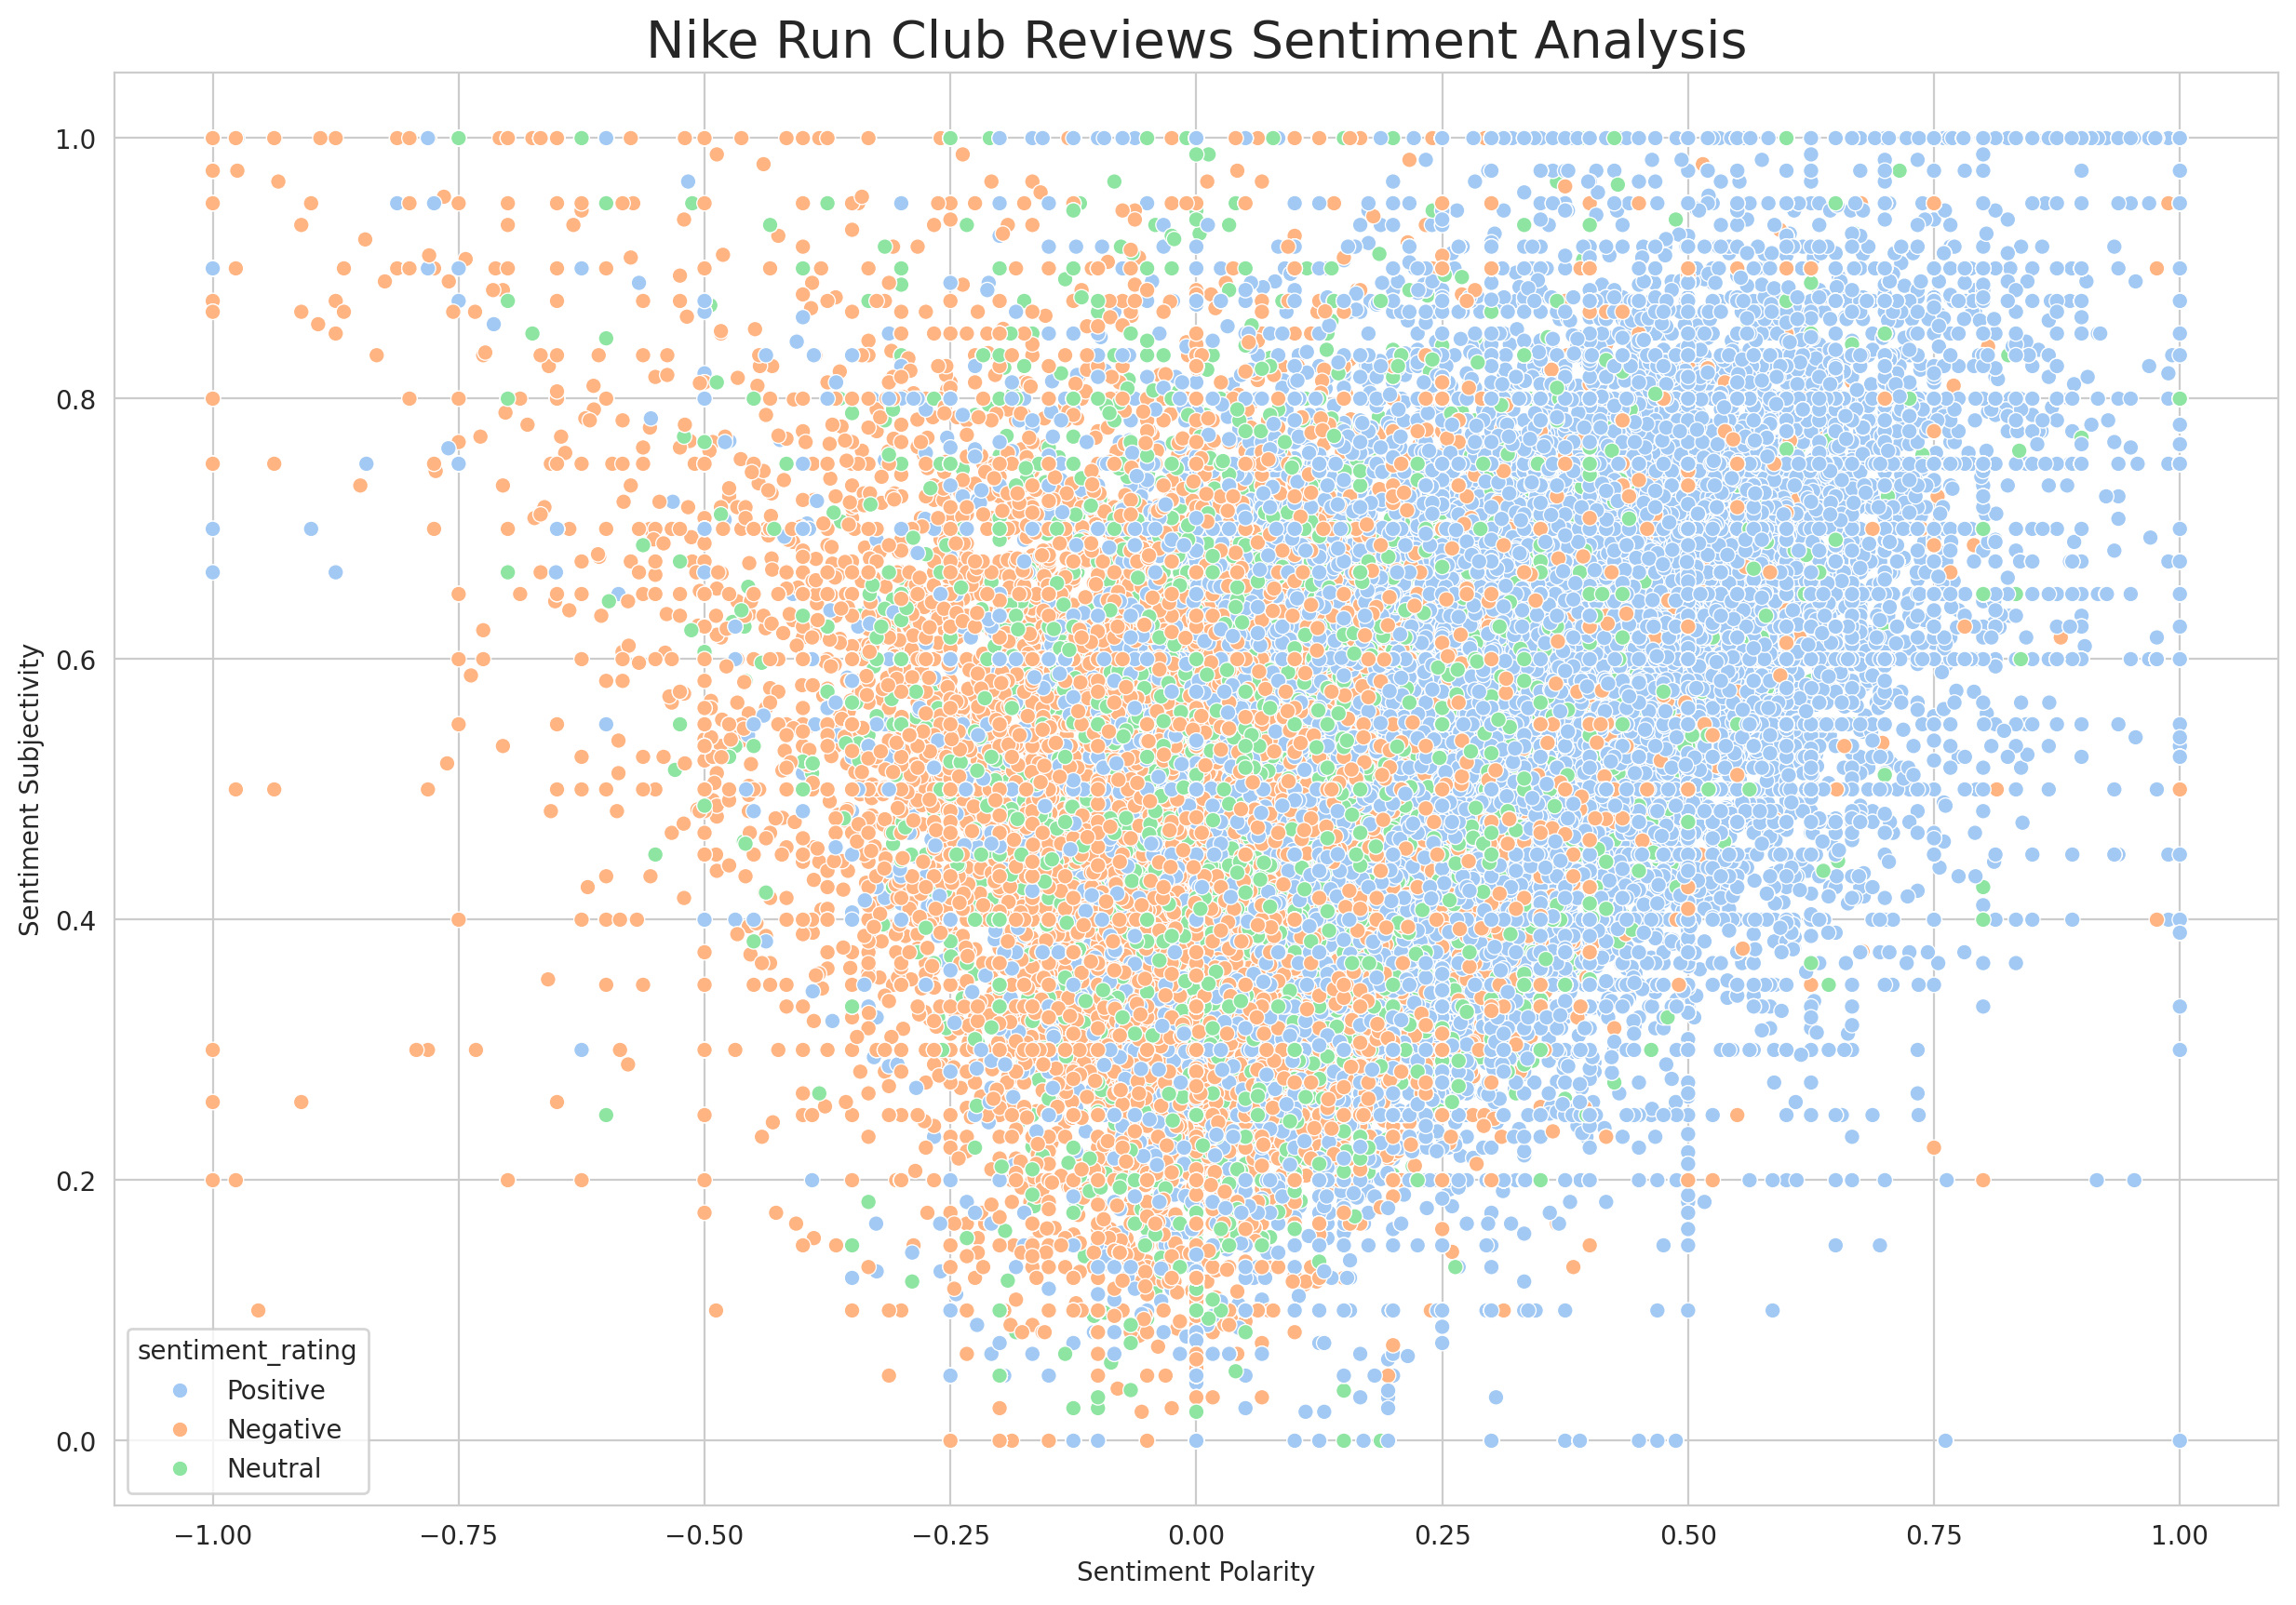

In [69]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat kolom sentiment polarity dan subjectivity berdasarkan review (content)
df_nike_reviews['sentiment_polarity'] = df_nike_reviews['content'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_nike_reviews['sentiment_subjectivity'] = df_nike_reviews['content'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Menambahkan kolom sentiment rating berdasarkan score review
df_nike_reviews['sentiment_rating'] = df_nike_reviews['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)

# Visualisasi Scatter Plot Sentiment Analysis
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_nike_reviews['sentiment_polarity'], y=df_nike_reviews['sentiment_subjectivity'],
                hue=df_nike_reviews['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Nike Run Club Reviews Sentiment Analysis", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.grid(True)
plt.show()


# Preprocessing Data

Sebelum menganalisis lebih lanjut, kita harus memahami tipe dan informasi lainnya terkait data yang telah kita miliki.

Dengan menggunakan fungsi info, dapat dilihat bahwa kolom "reviewCreatedVersion", "replyContent", "repliedAt", dan "appVersion" memiliki nilai null.

Selanjutnya kita ingin melihat semua nilai unik dalam kolom 'reviewCreatedVersion' untuk mengetahui versi apa saja yang tersedia pada review app Nike Run Club yang telah kita ambil.

In [70]:
# Melihat semua nilai unik dalam kolom 'reviewCreatedVersion'
unique_versions = df_nike_reviews.reviewCreatedVersion.unique()
print("Versi Aplikasi yang Unik dalam Review:")
print(unique_versions)

# Menampilkan jumlah versi aplikasi yang unik dalam review
num_unique_versions = df_nike_reviews.reviewCreatedVersion.nunique()
print(f"\nJumlah versi aplikasi dalam review yang diambil adalah: {num_unique_versions}")


Versi Aplikasi yang Unik dalam Review:
['4.64.0' '2.9.0' '2.8.0' nan '4.63.1' '1.2.1' '4.33.0' '4.42.0' '2.6.0'
 '1.3.0' '4.36.1' '4.38.0' '4.26.0' '4.6.0' '1.2.2' '2.2.0' '4.62.0' '1.4'
 '4.17.0' '4.40.0' '4.41.0' '4.37.0' '4.16.0' '4.13.0' '4.39.0' '4.24.0'
 '4.19.1' '1.1.0' '4.30.0' '4.32.0' '4.28.0' '4.35.0' '2.0.1' '2.7.0'
 '4.15.1' '4.12.1' '2.5.0' '2.4.0' '2.3.0' '2.0.3' '3.13.2' '3.2.0'
 '4.5.1' '4.31.0' '4.2.2' '4.21.0' '4.34.0' '4.36.0' '3.3.0' '4.18.0'
 '4.14.0' '4.29.0' '2.1.0' '3.5.1' '4.7.1' '4.25.0' '4.10.0' '3.0.2'
 '1.7.9' '4.15.2' '3.15.0' '4.20.0' '4.22.0' '2.14.1' '3.11.1' '2.25.0'
 '4.27.0' '3.8.1' '4.4.1' '4.23.0' '1.3.4' '1.0.3' '2.15.2' '3.6.0'
 '3.7.1' '2.19.1' '4.11.0' '3.1.0' '4.9.7' '1.7' '4.8.0' '4.4.0' '2.13.2'
 '1.3.2' '2.7.1' '2.11.2' '4.15.0' '4.19.0' '2.20.2' '3.12.0' '3.14.0'
 '3.10.1' '2.24.1' '2.10.1' '2.21.1' '2.18.4' '3.0.0' '3.8.0' '2.20.1'
 '2.0.5' '3.13.1' '3.4.0' '2.26.0' '2.22.2' '2.18.2' '3.9.1' '4.7.0'
 '3.5.0' '2.8.1' '2.16.0' '2.17.0' '2.

## Menghapus Emoji dan Spesial Karakter

In [71]:
import re
import string

# Fungsi untuk menghapus emoji dan membersihkan teks
def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese characters
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def clean_text(text):
    if not isinstance(text, str):
        return ""  # Jika bukan string, return kosong

    # Hapus emoji dulu
    text = remove_emojis(text)

    # Menambah spasi setelah koma jika tidak ada
    text = re.sub(r",(?!\s)", ", ", text)

    # Menghapus karakter non-ASCII
    text = text.encode('ascii', 'replace').decode('ascii')

    # Menghapus URL
    text = re.sub(r"(?i)(?:https?:\/\/)?(?:www\.)?(?:[a-zA-Z0-9-.]+)(?:\.[a-zA-Z]{2,6})(?:\/[^\s\r\n]*)?", "", text)

    # Menghapus whitespace di depan/belakang teks dan spasi ganda
    text = text.strip()
    text = re.sub('\s+', ' ', text)

    # Menghapus tanda baca
    text = text.translate(str.maketrans("", "", string.punctuation))

    return text

# Terapkan fungsi pembersihan ke kolom review
df_nike_reviews['content'] = df_nike_reviews['content'].apply(clean_text)

# Tampilkan hasil
print(df_nike_reviews[['content']].head())

                                             content
1  The Nike Run Club is the best The App tracks p...
2  This app has various guided training options t...
3  I like everything the app has to offer from gu...
4         easy to use beginner friendly im not a bot
5  I wouldnt have run my first half maranthon goa...


In [72]:
df_nike_reviews

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating
1,The Nike Run Club is the best The App tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,2,0.800000,0.650000,Positive
2,This app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,3,0.300000,0.750000,Positive
3,I like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,4.64.0,4,0.000000,0.333333,Negative
4,easy to use beginner friendly im not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,5,0.404167,0.666667,Positive
5,I wouldnt have run my first half maranthon goa...,5,0,4.64.0,2025-03-24 14:45:33,4.64.0,6,0.033333,0.400000,Positive
...,...,...,...,...,...,...,...,...,...,...
126511,Im really excited that this app has finally sh...,4,2,1.0.0,2012-06-21 23:37:49,1.0.0,126512,0.171429,0.633333,Positive
126513,Great for anyone who starts running or training,5,0,NaN,2012-06-21 23:31:12,NaN,126514,1.000000,0.750000,Positive
126514,This is soooo much better then the Iphone app ...,5,1,NaN,2012-06-21 23:16:50,NaN,126515,0.668333,0.720000,Positive
126515,Just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,1.0.0,126516,0.397273,0.579004,Positive


## Menghapus Review yang Kosong

Menghapus emoji dan karakter spesial memungkinkan beberapa review menjadi kosong, sehingga kita harus mengecek dan menghapusnya bila ada.

In [73]:
# Menghapus review yang bernilai kosong
df_nike_reviews = df_nike_reviews[df_nike_reviews['content'] != '']

In [74]:
# Memeriksa apakah masih ada review kosong pada kolom 'content'
df_nike_reviews[df_nike_reviews['content'] == '']

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating


In [75]:
# Menghapus review yang kosong atau hanya berisi spasi
df_nike_reviews = df_nike_reviews[df_nike_reviews['content'].str.strip() != '']

# Menghapus review yang berisi nilai NaN (null)
df_nike_reviews = df_nike_reviews.dropna(subset=['content'])

# Memeriksa kembali apakah masih ada nilai kosong
print(df_nike_reviews[df_nike_reviews['content'].str.strip() == ''])


Empty DataFrame
Columns: [content, score, thumbsUpCount, reviewCreatedVersion, at, appVersion, id, sentiment_polarity, sentiment_subjectivity, sentiment_rating]
Index: []


In [76]:
# Menampilkan jumlah data setelah preprocessing
df_nike_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 8.7+ MB


## Lowercasing Reviews

Membuat seluruh teks pada kolom 'content' menjadi huruf kecil menjadi hal yang penting agar teks menjadi konsisten dan homogen. Hal ini juga bertujuan untuk meningkatkan akurasi dari setiap teks.

In [77]:
# Mengubah tipe data kolom 'content' menjadi string
df_nike_reviews.loc[:, 'content'] = df_nike_reviews['content'].astype(str)

In [78]:
# Mengubah semua teks di kolom 'content' menjadi huruf kecil
df_nike_reviews.loc[:, 'content'] = df_nike_reviews['content'].apply(lambda x: x.lower())

In [79]:
# Menampilkan hasil
df_nike_reviews

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating
1,the nike run club is the best the app tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,2,0.800000,0.650000,Positive
2,this app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,3,0.300000,0.750000,Positive
3,i like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,4.64.0,4,0.000000,0.333333,Negative
4,easy to use beginner friendly im not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,5,0.404167,0.666667,Positive
5,i wouldnt have run my first half maranthon goa...,5,0,4.64.0,2025-03-24 14:45:33,4.64.0,6,0.033333,0.400000,Positive
...,...,...,...,...,...,...,...,...,...,...
126511,im really excited that this app has finally sh...,4,2,1.0.0,2012-06-21 23:37:49,1.0.0,126512,0.171429,0.633333,Positive
126513,great for anyone who starts running or training,5,0,NaN,2012-06-21 23:31:12,NaN,126514,1.000000,0.750000,Positive
126514,this is soooo much better then the iphone app ...,5,1,NaN,2012-06-21 23:16:50,NaN,126515,0.668333,0.720000,Positive
126515,just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,1.0.0,126516,0.397273,0.579004,Positive


## Expand Contraxtions

Mengubah bentuk singkatan menjadi bentuk panjang agar teks lebih mudah diproses dan dianalisis dengan benar. Misalnya, kata "can't" akan diubah menjadi "cannot", dan "it's" menjadi "it is".

In [80]:
!pip install spacy
!pip install contractions
import spacy
import contractions

In [81]:
# Expand contractions untuk dataset Nike Run Club
def expand_contractions(text):
    return contractions.fix(text)  # Contoh: "can't" → "cannot"

# Terapkan pada kolom 'content'
df_nike_reviews['content'] = df_nike_reviews['content'].apply(expand_contractions)

# Tampilkan hasil contoh
df_nike_reviews[['content']].head()

,content
1,the nike run club is the best the app tracks p...
2,this app has various guided training options t...
3,i like everything the app has to offer from gu...
4,easy to use beginner friendly i am not a bot
5,i would not have run my first half maranthon g...


## Spell Corection

In [82]:
!pip install symspellpy


In [83]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # Download 'punkt_tab' yang hilang


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [84]:
from symspellpy import SymSpell, Verbosity  # Perbaikan di sini
import pkg_resources
import nltk
import re
from nltk.tokenize import word_tokenize

# Setup SymSpell
nltk.download('punkt')

# Load dictionary paths
dictionary_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
bigram_path = pkg_resources.resource_filename("symspellpy", "frequency_bigramdictionary_en_243_342.txt")

# Initialize SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
sym_spell.load_bigram_dictionary(bigram_path, term_index=0, count_index=2)

def enhanced_correct_spelling(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove non-alphabetic characters
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    corrected_words = []

    for word in words:
        suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)  # Perbaikan di sini
        corrected_words.append(suggestions[0].term if suggestions else word)

    corrected_text = " ".join(corrected_words)
    suggestions = sym_spell.lookup_compound(corrected_text, max_edit_distance=2)

    return suggestions[0].term if suggestions else corrected_text

# Terapkan spell correction ke dataframe
df_nike_reviews['final_cleaned'] = df_nike_reviews['content'].apply(enhanced_correct_spelling)

df_nike_reviews

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating,final_cleaned
1,the nike run club is the best the app tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,2,0.800000,0.650000,Positive,the nike run club is the best the app tracks p...
2,this app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,3,0.300000,0.750000,Positive,this app has various guided training options t...
3,i like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,4.64.0,4,0.000000,0.333333,Negative,i like everything the app has to offer from gu...
4,easy to use beginner friendly i am not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,5,0.404167,0.666667,Positive,easy to use beginner friendly i am not a bot
5,i would not have run my first half maranthon g...,5,0,4.64.0,2025-03-24 14:45:33,4.64.0,6,0.033333,0.400000,Positive,i would not have run my first half marathon go...
...,...,...,...,...,...,...,...,...,...,...,...
126511,i am really excited that this app has finally ...,4,2,1.0.0,2012-06-21 23:37:49,1.0.0,126512,0.171429,0.633333,Positive,i am really excited that this app has finally ...
126513,great for anyone who starts running or training,5,0,NaN,2012-06-21 23:31:12,NaN,126514,1.000000,0.750000,Positive,great for anyone who starts running or training
126514,this is soooo much better then the iphone app ...,5,1,NaN,2012-06-21 23:16:50,NaN,126515,0.668333,0.720000,Positive,this is soon much better then the iphone app g...
126515,just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,1.0.0,126516,0.397273,0.579004,Positive,just completed my first run with this new app ...


In [85]:
import re

def handle_negation(text):
    # Gabungkan kata negatif dengan kata sifat atau kata kerja
    negation_patterns = r'\b(?:not|no|never|none|n\'t)\s+(\w+)'
    text = re.sub(negation_patterns, lambda match: match.group(0).replace(" ", "_"), text)
    return text
# Terapkan handle_negation lebih awal
df_nike_reviews['final_cleaned'] = df_nike_reviews['final_cleaned'].apply(handle_negation)

## Punctuation Removal

In [86]:
import string

def remove_punctuation(text):
    """Menghapus tanda baca dari teks."""
    return text.translate(str.maketrans("", "", string.punctuation))

# Terapkan pada kolom 'final_cleaned' setelah spell correction
df_nike_reviews['final_cleaned'] = df_nike_reviews['final_cleaned'].apply(remove_punctuation)

# Tampilkan hasil
df_nike_reviews[['final_cleaned']].head()


,final_cleaned
1,the nike run club is the best the app tracks p...
2,this app has various guided training options t...
3,i like everything the app has to offer from gu...
4,easy to use beginner friendly i am nota bot
5,i would nothave run my first half marathon goa...


## Tokenization

In [87]:
!pip install nltk

In [88]:
import nltk
from nltk.tokenize import word_tokenize

# Download the 'punkt' resource jika belum ada
nltk.download('punkt')

# Tokenize pada kolom 'final_cleaned' setelah punctuation removal
df_nike_reviews['token'] = df_nike_reviews['final_cleaned'].apply(word_tokenize)

# Tampilkan hasil
df_nike_reviews[['final_cleaned', 'token']].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,final_cleaned,token
1,the nike run club is the best the app tracks p...,"[the, nike, run, club, is, the, best, the, app..."
2,this app has various guided training options t...,"[this, app, has, various, guided, training, op..."
3,i like everything the app has to offer from gu...,"[i, like, everything, the, app, has, to, offer..."
4,easy to use beginner friendly i am nota bot,"[easy, to, use, beginner, friendly, i, am, not..."
5,i would nothave run my first half marathon goa...,"[i, would, nothave, run, my, first, half, mara..."


In [89]:
# Display results
print(df_nike_reviews[['final_cleaned', 'token']])

                                            final_cleaned  \
1       the nike run club is the best the app tracks p...   
2       this app has various guided training options t...   
3       i like everything the app has to offer from gu...   
4             easy to use beginner friendly i am nota bot   
5       i would nothave run my first half marathon goa...   
...                                                   ...   
126511  i am really excited that this app has finally ...   
126513    great for anyone who starts running or training   
126514  this is soon much better then the iphone app g...   
126515  just completed my first run with this new app ...   
126517  i have been waiting a long time for nike to co...   

                                                    token  
1       [the, nike, run, club, is, the, best, the, app...  
2       [this, app, has, various, guided, training, op...  
3       [i, like, everything, the, app, has, to, offer...  
4       [easy, to, use, beg

In [90]:
df_nike_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
 10  final_cleaned           103706 non-null  object 
 11  token                   103706 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 10.3+ MB


## Stopwords Removal

In [91]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Ambil stopwords bahasa Inggris dari NLTK
english_stopwords = set(stopwords.words('english'))

# Kata negatif utama yang tidak boleh dihapus
negation_words = {'not', 'no', 'never', "n't", 'none'}

# Hilangkan kata negatif dari stopwords
english_stopwords = english_stopwords.difference(negation_words)

# Tambahkan stopwords tambahan jika diperlukan (termasuk kata positif umum)
additional_stopwords = {
    'nike', 'shoes', 'shoe', 'sneakers', 'sneaker', 'app', 'product', 'pair',
    'run', 'runs', 'running', 'use', 'using', 'get', 'keeps', 'time', 'track',
    'tracking', 'like', 'would', 'update', 'keep', 'used', 'one', 'please',
    'even', 'distance', 'gps', 'work', 'works', 'training', 'also', 'fix', 'back',
    'could', 'miles', 'every', 'lot', 'thing', 'stuff', 'many', 'always',
    'never', 'ever', 'seems', 'actually', 'really', 'much', 'still'
}

# Update stopwords final tanpa menghapus kata negatif
english_stopwords.update(additional_stopwords)

# Stopwords removal setelah negation handling
def stopwords_removal(tokens):
    cleaned_tokens = []
    for word in tokens:
        if word.lower() not in english_stopwords and word.isalpha():
            # Pertahankan kata negatif yang digabung dengan kata positif
            if '_' in word and any(neg in word for neg in negation_words):
                cleaned_tokens.append(word)
            elif word.lower() not in english_stopwords:
                cleaned_tokens.append(word)
    return cleaned_tokens

df_nike_reviews['token_after_sr'] = df_nike_reviews['token'].apply(stopwords_removal)

# Cek hasilnya
print(df_nike_reviews[['token', 'token_after_sr']].head(10))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                token  \
1   [the, nike, run, club, is, the, best, the, app...   
2   [this, app, has, various, guided, training, op...   
3   [i, like, everything, the, app, has, to, offer...   
4   [easy, to, use, beginner, friendly, i, am, not...   
5   [i, would, nothave, run, my, first, half, mara...   
6   [one, step, at, a, time, good, app, for, fitne...   
7   [its, a, great, app, when, it, works, recently...   
8   [so, helpful, i, am, a, beginner, runner, and,...   
9   [edit, app, logs, me, out, every, so, often, a...   
10                                   [offline, works]   

                                       token_after_sr  
1   [club, best, tracks, progress, graphically, ge...  
2   [various, guided, options, help, runners, trai...  
3   [everything, offer, guidance, challenges, cons...  
4               [easy, beginner, friendly, nota, bot]  
5   [nothave, first, half, marathon, goal, without...  
6                   [step, good, fit

In [92]:
from collections import Counter
import matplotlib.pyplot as plt

def freq_words(tokens_column, top_n=20):
    all_words = [word for tokens in tokens_column for word in tokens]
    word_freq = Counter(all_words).most_common(top_n)

    words, counts = zip(*word_freq)

    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title("Top Frequent Words")
    plt.show()


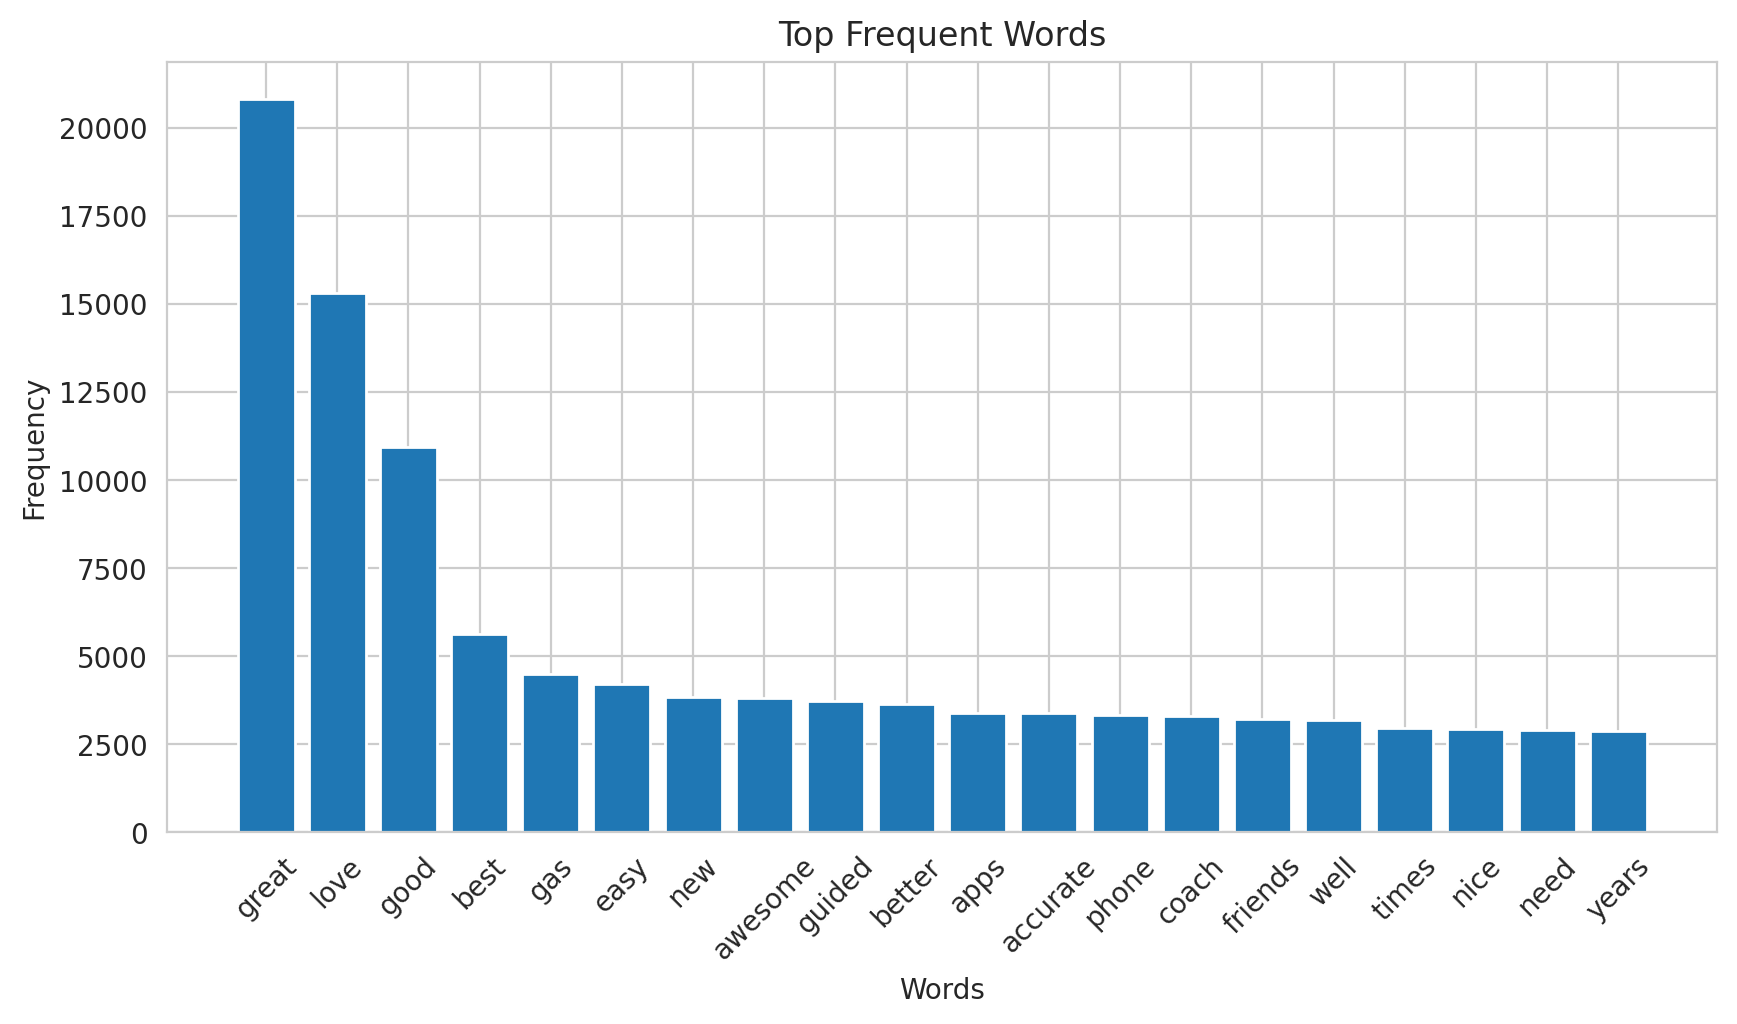

In [93]:
freq_words(df_nike_reviews['token_after_sr'])

## Lemmatization

In [94]:
df_nike_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
 10  final_cleaned           103706 non-null  object 
 11  token                   103706 non-null  object 
 12  token_after_sr          103706 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 11.1+ MB


In [96]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')  # Tambahkan resource untuk lemmatization yang lebih akurat
from nltk.stem import WordNetLemmatizer

# Inisialisasi lemmatizer
lemmatizer = WordNetLemmatizer()

# Fungsi untuk lemmatization pada tokens
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Lakukan lemmatization pada kolom token_after_sr yang sudah dibersihkan dari stopwords
df_nike_reviews['lemmatized_tokens'] = df_nike_reviews['token_after_sr'].apply(lemmatize_text)

# Tampilkan hasil untuk melihat perubahan
display(df_nike_reviews[['final_cleaned', 'token_after_sr', 'lemmatized_tokens']])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,final_cleaned,token_after_sr,lemmatized_tokens
1,the nike run club is the best the app tracks p...,"[club, best, tracks, progress, graphically, ge...","[club, best, track, progress, graphically, geo..."
2,this app has various guided training options t...,"[various, guided, options, help, runners, trai...","[various, guided, option, help, runner, train,..."
3,i like everything the app has to offer from gu...,"[everything, offer, guidance, challenges, cons...","[everything, offer, guidance, challenge, const..."
4,easy to use beginner friendly i am nota bot,"[easy, beginner, friendly, nota, bot]","[easy, beginner, friendly, nota, bot]"
5,i would nothave run my first half marathon goa...,"[nothave, first, half, marathon, goal, without...","[nothave, first, half, marathon, goal, without..."
...,...,...,...
126511,i am really excited that this app has finally ...,"[excited, finally, shown, android, far, looks,...","[excited, finally, shown, android, far, look, ..."
126513,great for anyone who starts running or training,"[great, anyone, starts]","[great, anyone, start]"
126514,this is soon much better then the iphone app g...,"[soon, better, iphone, good, job, great, see, ...","[soon, better, iphone, good, job, great, see, ..."
126515,just completed my first run with this new app ...,"[completed, first, new, worked, great, nice, i...","[completed, first, new, worked, great, nice, i..."


In [97]:
df_nike_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
 10  final_cleaned           103706 non-null  object 
 11  token                   103706 non-null  object 
 12  token_after_sr          103706 non-null  object 
 13  lemmatized_tokens       103706 non-null  object 
dtypes: float64(2), int64(3), 

# Sentiment Analysis after Text Preprocessing

In [98]:
# Gabungkan kembali token setelah lemmatization menjadi kalimat utuh
df_nike_reviews['cleaned_text'] = df_nike_reviews['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens))

# Cek hasil
display(df_nike_reviews[['lemmatized_tokens', 'cleaned_text']])

,lemmatized_tokens,cleaned_text
1,"[club, best, track, progress, graphically, geo...",club best track progress graphically geographi...
2,"[various, guided, option, help, runner, train,...",various guided option help runner train goal w...
3,"[everything, offer, guidance, challenge, const...",everything offer guidance challenge constantly...
4,"[easy, beginner, friendly, nota, bot]",easy beginner friendly nota bot
5,"[nothave, first, half, marathon, goal, without...",nothave first half marathon goal without help ...
...,...,...
126511,"[excited, finally, shown, android, far, look, ...",excited finally shown android far look great n...
126513,"[great, anyone, start]",great anyone start
126514,"[soon, better, iphone, good, job, great, see, ...",soon better iphone good job great see create g...
126515,"[completed, first, new, worked, great, nice, i...",completed first new worked great nice integrat...


In [99]:
df_nike_reviews2 = df_nike_reviews.copy()

In [100]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
 10  final_cleaned           103706 non-null  object 
 11  token                   103706 non-null  object 
 12  token_after_sr          103706 non-null  object 
 13  lemmatized_tokens       103706 non-null  object 
 14  cleaned_text            1

In [101]:
df_nike_reviews2.drop(columns=['sentiment_polarity', 'sentiment_subjectivity'])

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_rating,final_cleaned,token,token_after_sr,lemmatized_tokens,cleaned_text
1,the nike run club is the best the app tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,2,Positive,the nike run club is the best the app tracks p...,"[the, nike, run, club, is, the, best, the, app...","[club, best, tracks, progress, graphically, ge...","[club, best, track, progress, graphically, geo...",club best track progress graphically geographi...
2,this app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,3,Positive,this app has various guided training options t...,"[this, app, has, various, guided, training, op...","[various, guided, options, help, runners, trai...","[various, guided, option, help, runner, train,...",various guided option help runner train goal w...
3,i like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,4.64.0,4,Negative,i like everything the app has to offer from gu...,"[i, like, everything, the, app, has, to, offer...","[everything, offer, guidance, challenges, cons...","[everything, offer, guidance, challenge, const...",everything offer guidance challenge constantly...
4,easy to use beginner friendly i am not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,5,Positive,easy to use beginner friendly i am nota bot,"[easy, to, use, beginner, friendly, i, am, not...","[easy, beginner, friendly, nota, bot]","[easy, beginner, friendly, nota, bot]",easy beginner friendly nota bot
5,i would not have run my first half maranthon g...,5,0,4.64.0,2025-03-24 14:45:33,4.64.0,6,Positive,i would nothave run my first half marathon goa...,"[i, would, nothave, run, my, first, half, mara...","[nothave, first, half, marathon, goal, without...","[nothave, first, half, marathon, goal, without...",nothave first half marathon goal without help ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126511,i am really excited that this app has finally ...,4,2,1.0.0,2012-06-21 23:37:49,1.0.0,126512,Positive,i am really excited that this app has finally ...,"[i, am, really, excited, that, this, app, has,...","[excited, finally, shown, android, far, looks,...","[excited, finally, shown, android, far, look, ...",excited finally shown android far look great n...
126513,great for anyone who starts running or training,5,0,NaN,2012-06-21 23:31:12,NaN,126514,Positive,great for anyone who starts running or training,"[great, for, anyone, who, starts, running, or,...","[great, anyone, starts]","[great, anyone, start]",great anyone start
126514,this is soooo much better then the iphone app ...,5,1,NaN,2012-06-21 23:16:50,NaN,126515,Positive,this is soon much better then the iphone app g...,"[this, is, soon, much, better, then, the, ipho...","[soon, better, iphone, good, job, great, see, ...","[soon, better, iphone, good, job, great, see, ...",soon better iphone good job great see create g...
126515,just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,1.0.0,126516,Positive,just completed my first run with this new app ...,"[just, completed, my, first, run, with, this, ...","[completed, first, new, worked, great, nice, i...","[completed, first, new, worked, great, nice, i...",completed first new worked great nice integrat...


In [102]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
 10  final_cleaned           103706 non-null  object 
 11  token                   103706 non-null  object 
 12  token_after_sr          103706 non-null  object 
 13  lemmatized_tokens       103706 non-null  object 
 14  cleaned_text            1

In [103]:
# Mengisi missing values pada kolom 'cleaned_text' dengan string kosong
df_nike_reviews2['cleaned_text'] = df_nike_reviews2['cleaned_text'].fillna('')

# Hitung sentiment polarity dan subjectivity dengan penamaan kolom yang konsisten
df_nike_reviews2['sentiment_polarity'] = df_nike_reviews2['cleaned_text'].apply(lambda x: TextBlob(x).polarity)
df_nike_reviews2['sentiment_subjectivity'] = df_nike_reviews2['cleaned_text'].apply(lambda x: TextBlob(x).subjectivity)

In [104]:
df_nike_reviews2

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating,final_cleaned,token,token_after_sr,lemmatized_tokens,cleaned_text
1,the nike run club is the best the app tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,2,1.000000,0.300000,Positive,the nike run club is the best the app tracks p...,"[the, nike, run, club, is, the, best, the, app...","[club, best, tracks, progress, graphically, ge...","[club, best, track, progress, graphically, geo...",club best track progress graphically geographi...
2,this app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,3,0.000000,0.500000,Positive,this app has various guided training options t...,"[this, app, has, various, guided, training, op...","[various, guided, options, help, runners, trai...","[various, guided, option, help, runner, train,...",various guided option help runner train goal w...
3,i like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,4.64.0,4,0.000000,0.333333,Negative,i like everything the app has to offer from gu...,"[i, like, everything, the, app, has, to, offer...","[everything, offer, guidance, challenges, cons...","[everything, offer, guidance, challenge, const...",everything offer guidance challenge constantly...
4,easy to use beginner friendly i am not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,5,0.404167,0.666667,Positive,easy to use beginner friendly i am nota bot,"[easy, to, use, beginner, friendly, i, am, not...","[easy, beginner, friendly, nota, bot]","[easy, beginner, friendly, nota, bot]",easy beginner friendly nota bot
5,i would not have run my first half maranthon g...,5,0,4.64.0,2025-03-24 14:45:33,4.64.0,6,0.045833,0.400000,Positive,i would nothave run my first half marathon goa...,"[i, would, nothave, run, my, first, half, mara...","[nothave, first, half, marathon, goal, without...","[nothave, first, half, marathon, goal, without...",nothave first half marathon goal without help ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126511,i am really excited that this app has finally ...,4,2,1.0.0,2012-06-21 23:37:49,1.0.0,126512,0.222917,0.722222,Positive,i am really excited that this app has finally ...,"[i, am, really, excited, that, this, app, has,...","[excited, finally, shown, android, far, looks,...","[excited, finally, shown, android, far, look, ...",excited finally shown android far look great n...
126513,great for anyone who starts running or training,5,0,NaN,2012-06-21 23:31:12,NaN,126514,0.800000,0.750000,Positive,great for anyone who starts running or training,"[great, for, anyone, who, starts, running, or,...","[great, anyone, starts]","[great, anyone, start]",great anyone start
126514,this is soooo much better then the iphone app ...,5,1,NaN,2012-06-21 23:16:50,NaN,126515,0.626667,0.720000,Positive,this is soon much better then the iphone app g...,"[this, is, soon, much, better, then, the, ipho...","[soon, better, iphone, good, job, great, see, ...","[soon, better, iphone, good, job, great, see, ...",soon better iphone good job great see create g...
126515,just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,1.0.0,126516,0.357273,0.579004,Positive,just completed my first run with this new app ...,"[just, completed, my, first, run, with, this, ...","[completed, first, new, worked, great, nice, i...","[completed, first, new, worked, great, nice, i...",completed first new worked great nice integrat...


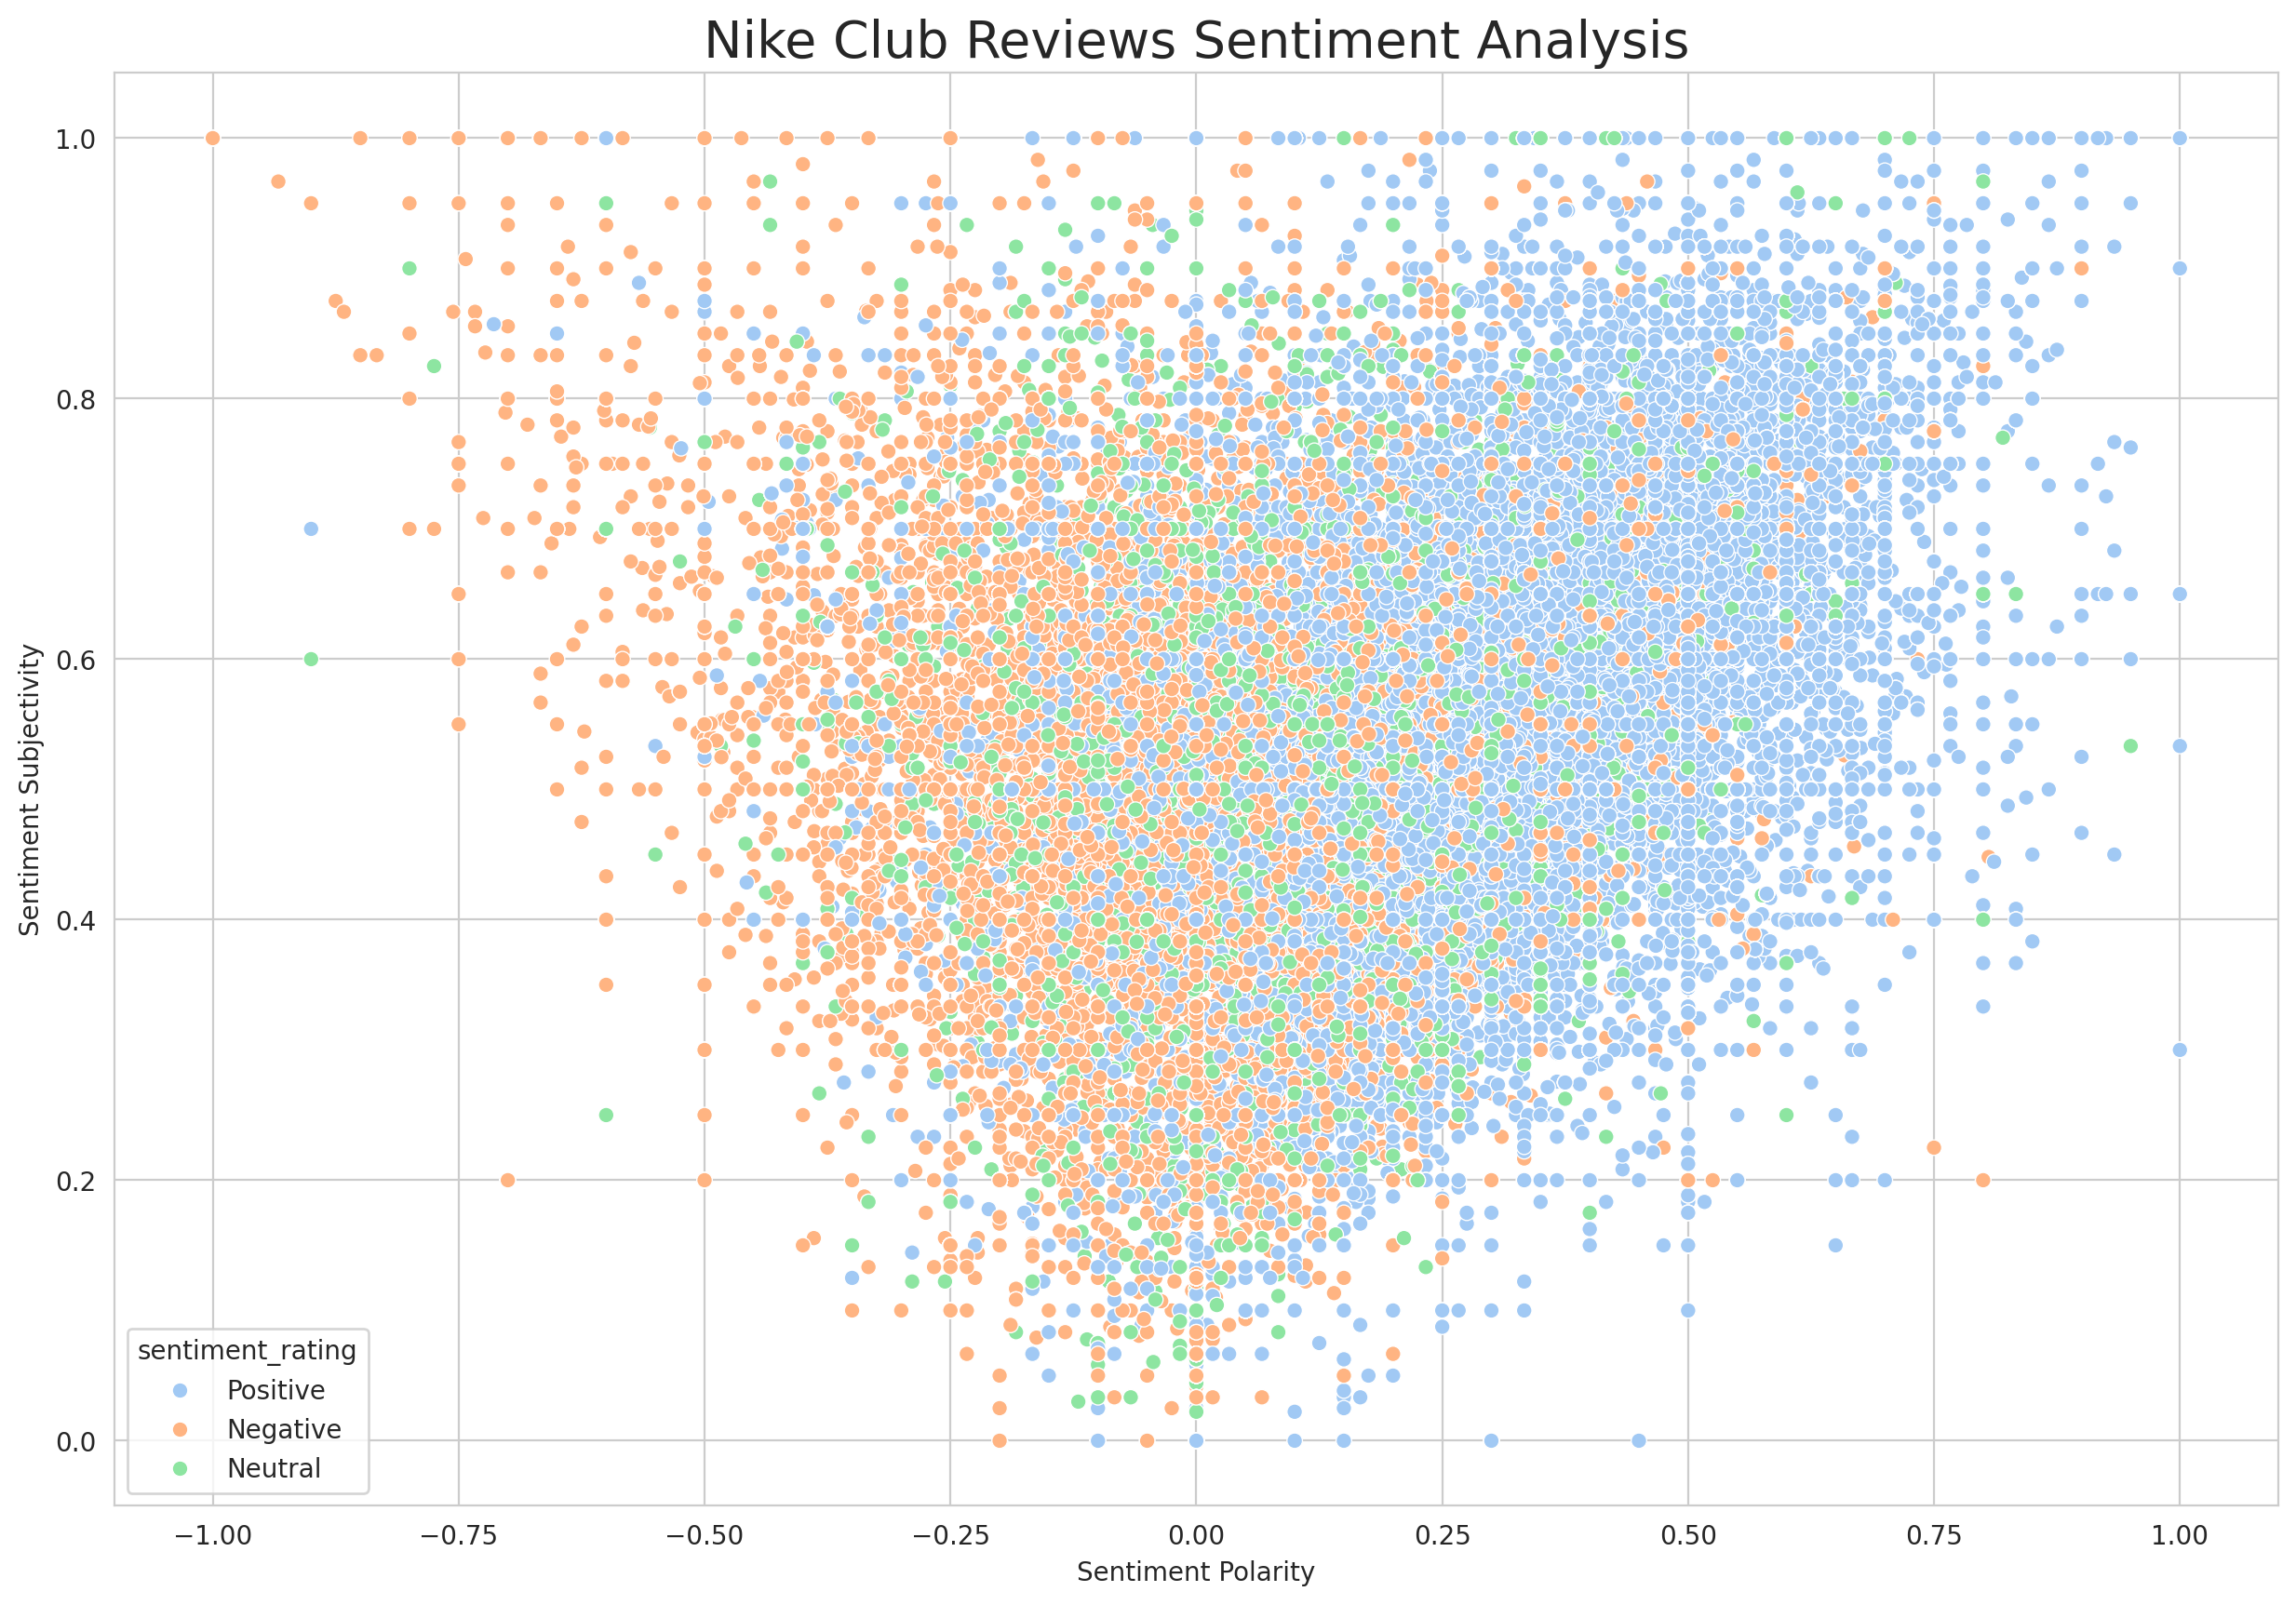

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_nike_reviews2['sentiment_polarity'],
                y=df_nike_reviews2['sentiment_subjectivity'],
                hue=df_nike_reviews2['sentiment_rating'],
                edgecolor='white',
                palette="pastel")
plt.title("Nike Club Reviews Sentiment Analysis", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.grid(True)
plt.show()


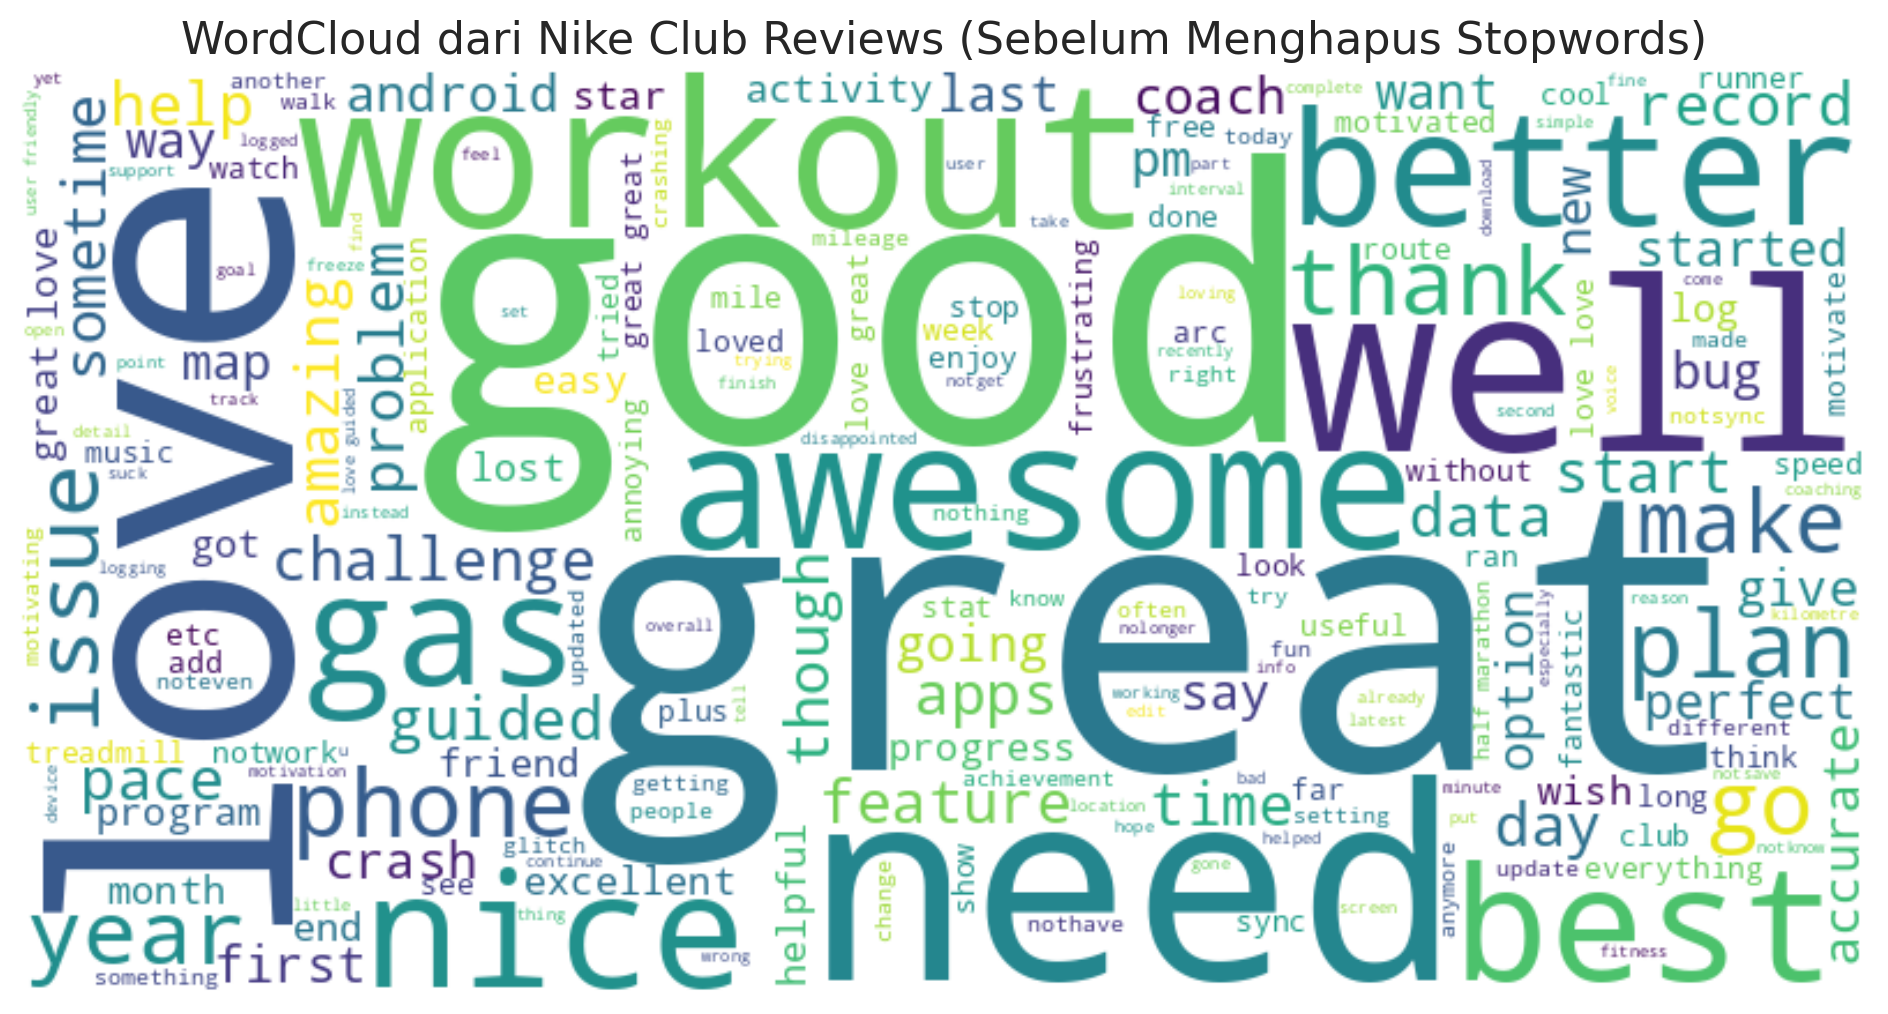

In [106]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Membuat WordCloud langsung dari kolom 'cleaned text'
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df_nike_reviews['cleaned_text']))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud dari Nike Club Reviews (Sebelum Menghapus Stopwords)", fontsize=16)
plt.show()


# Extract To New CSV

In [107]:
# Simpan DataFrame df_nike_reviews2 ke CSV
df_nike_reviews2.to_csv('df_nike_reviews2.csv', index=False, encoding='utf-8')

print("Data berhasil disimpan ke 'df_nike_reviews2.csv' 🎉")

Data berhasil disimpan ke 'df_nike_reviews2.csv' 🎉


# Exploratory Data Analysis

In [108]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103706 entries, 1 to 126517
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   content                 103706 non-null  object 
 1   score                   103706 non-null  int64  
 2   thumbsUpCount           103706 non-null  int64  
 3   reviewCreatedVersion    96138 non-null   object 
 4   at                      103706 non-null  object 
 5   appVersion              96138 non-null   object 
 6   id                      103706 non-null  int64  
 7   sentiment_polarity      103706 non-null  float64
 8   sentiment_subjectivity  103706 non-null  float64
 9   sentiment_rating        103706 non-null  object 
 10  final_cleaned           103706 non-null  object 
 11  token                   103706 non-null  object 
 12  token_after_sr          103706 non-null  object 
 13  lemmatized_tokens       103706 non-null  object 
 14  cleaned_text            1

## Review Score Distribution

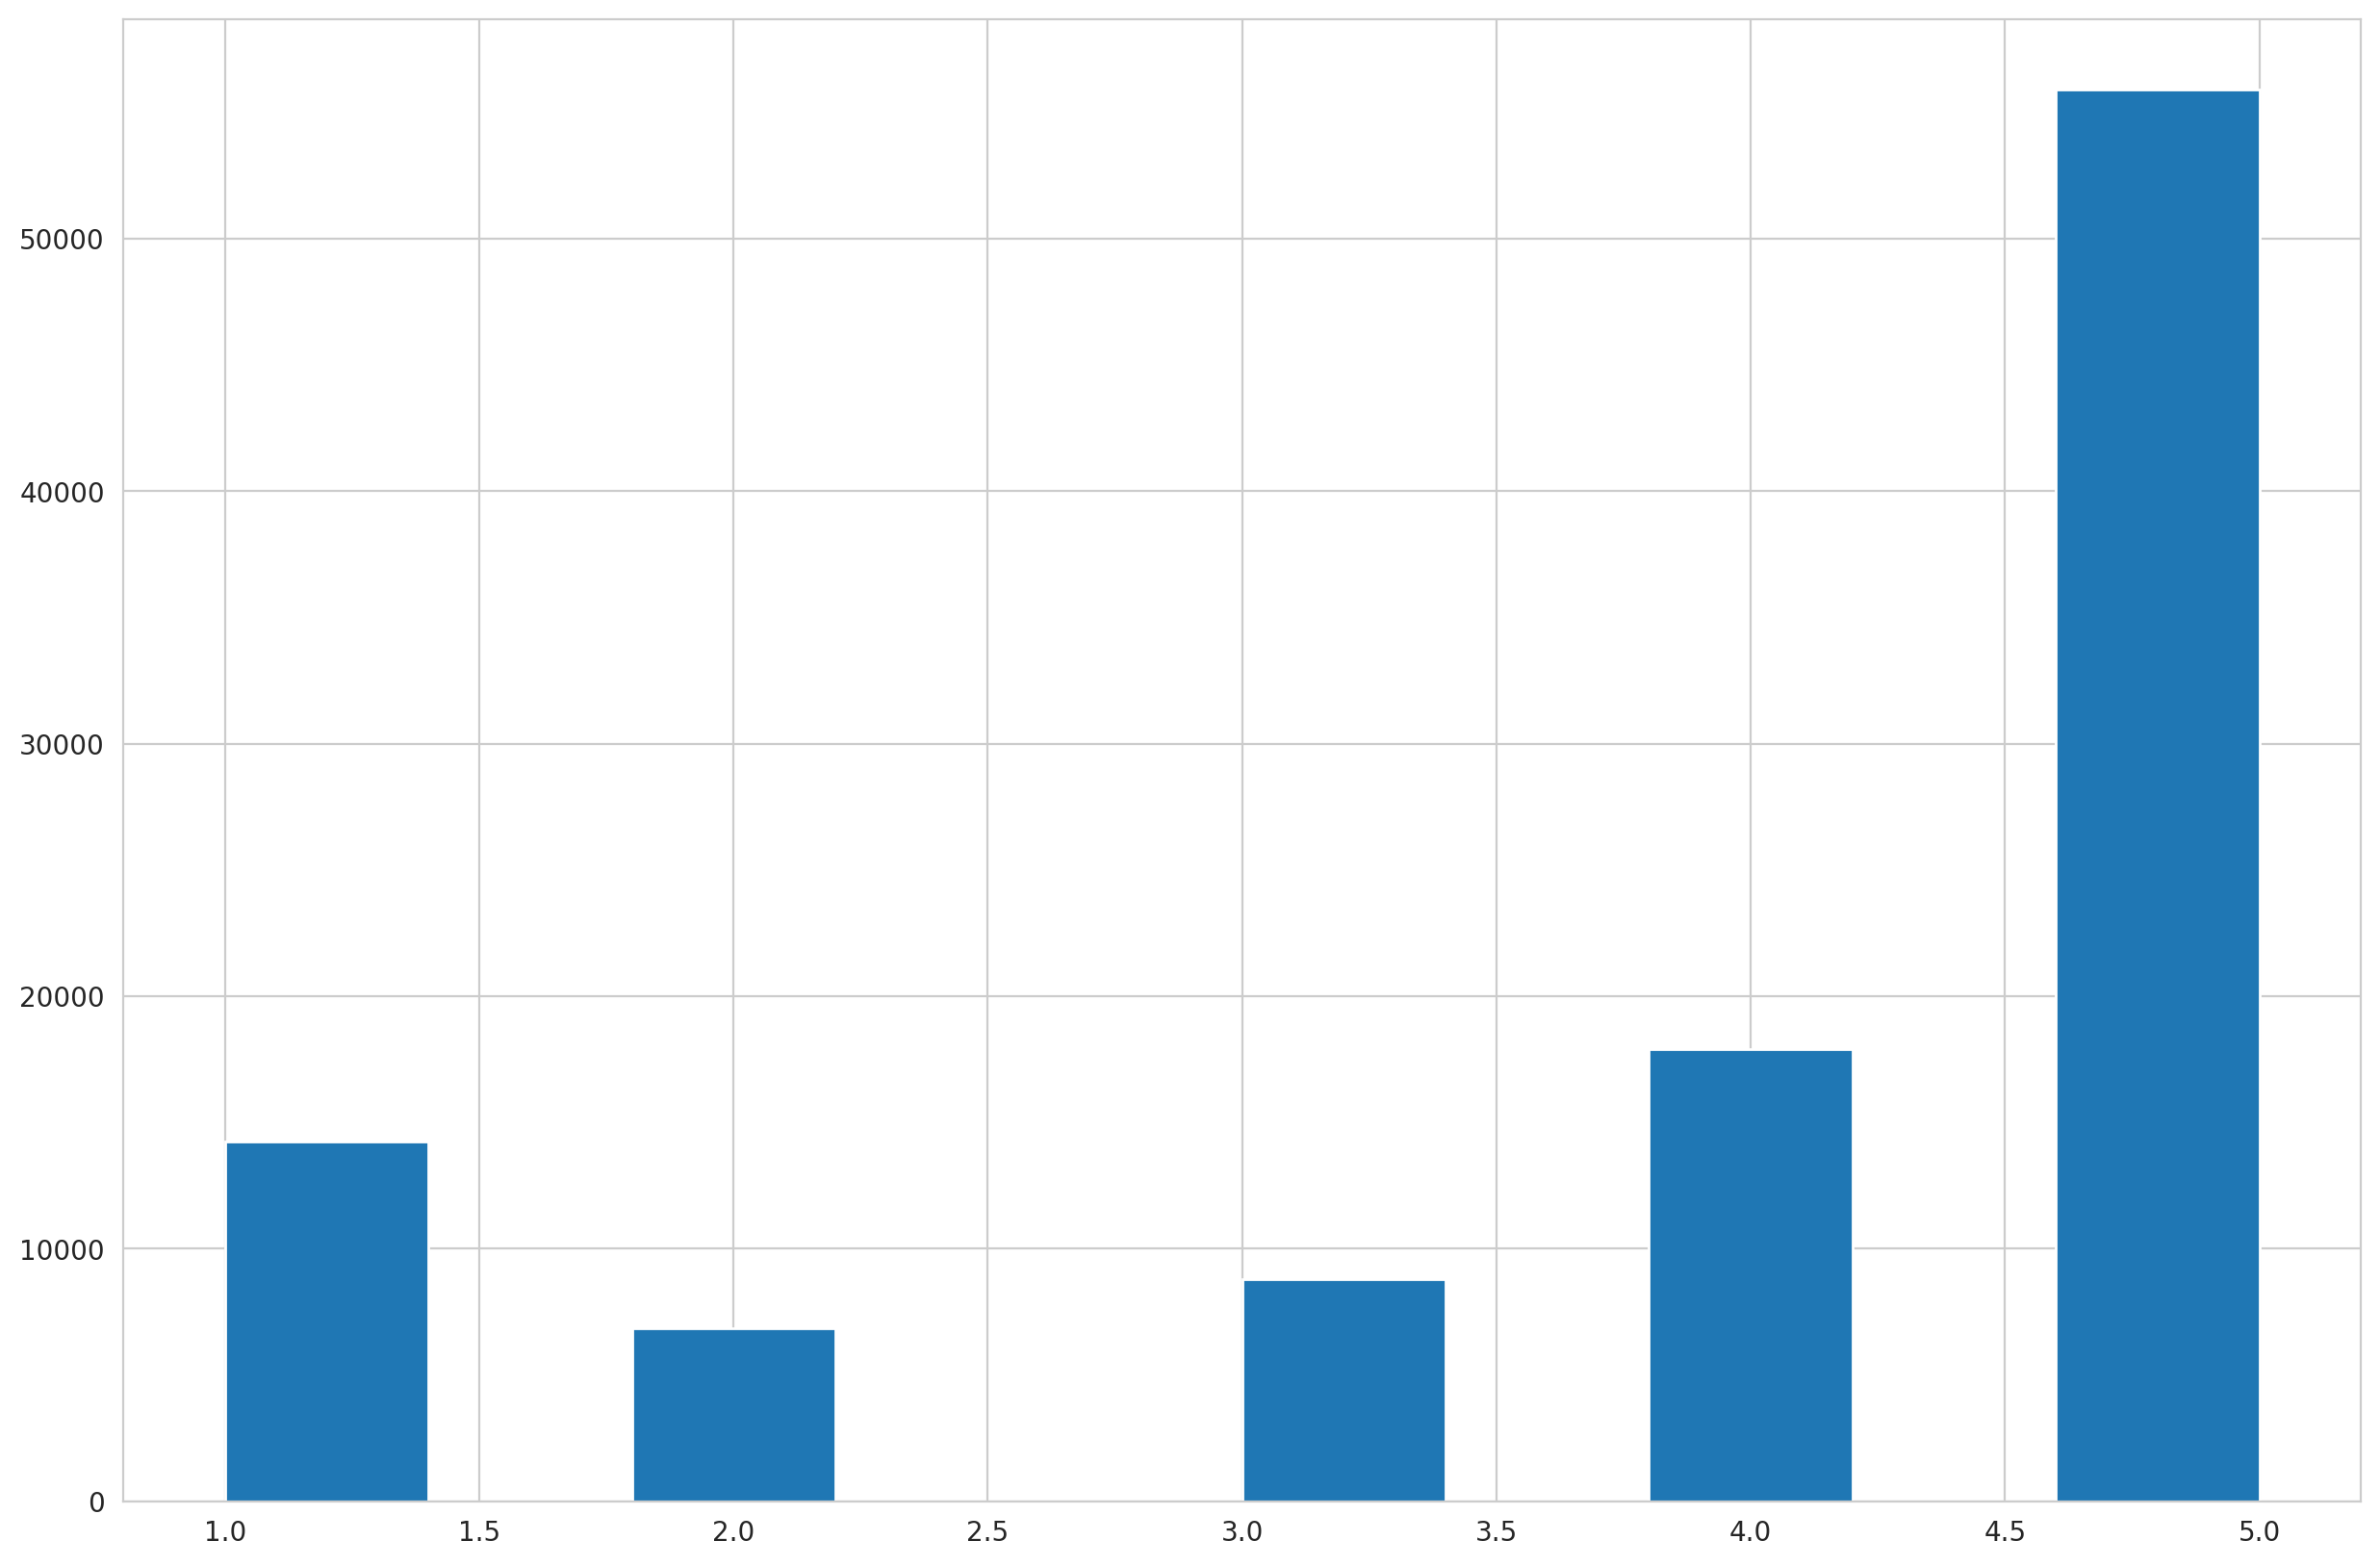

In [109]:
plt.hist(df_nike_reviews2['score'])
plt.show()

## Jumlah review per tahun

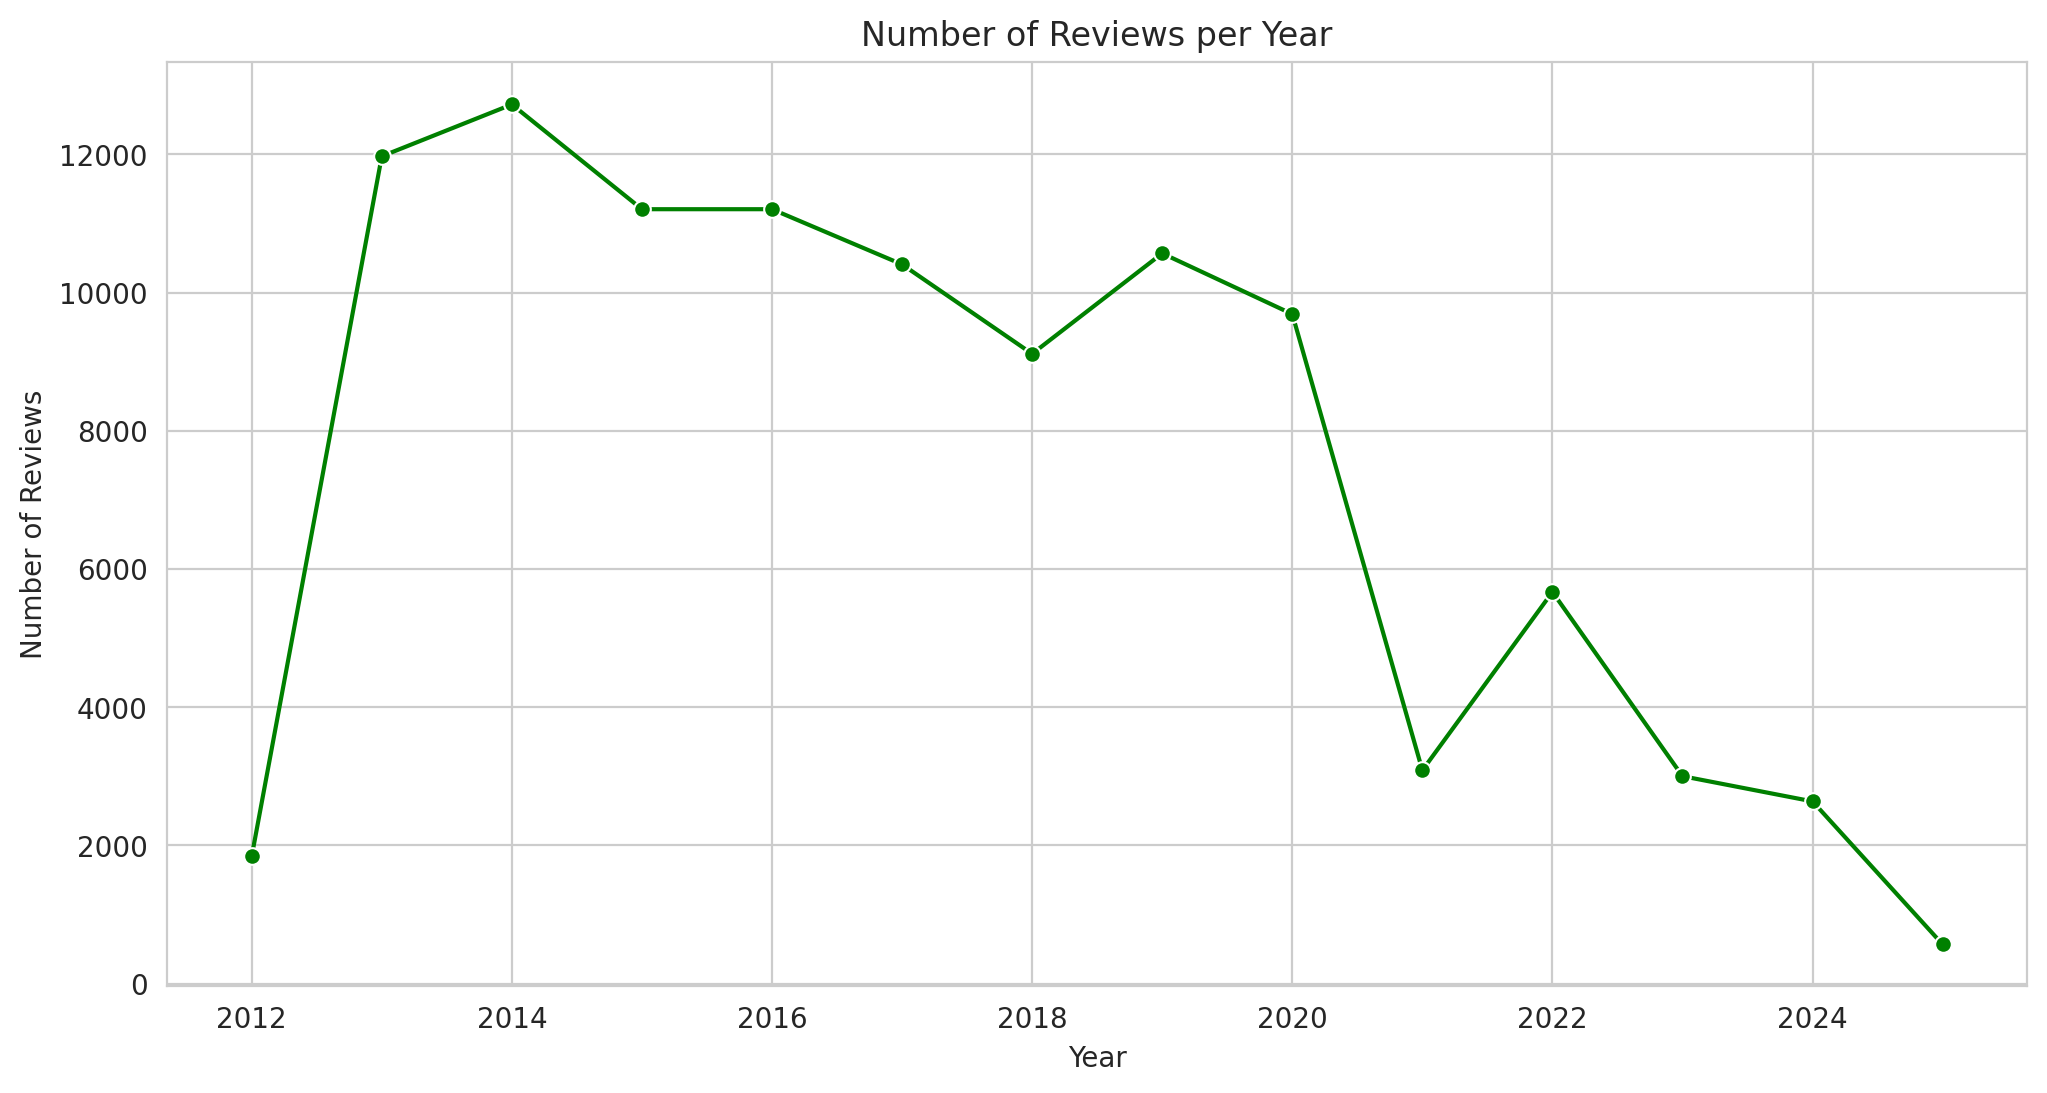

In [110]:
df_nike_reviews2['at'] = pd.to_datetime(df_nike_reviews2['at'])
df_nike_reviews2['year'] = df_nike_reviews2['at'].dt.year
year_counts = df_nike_reviews2['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

## Jumlah review tiap bulan di setiap tahun

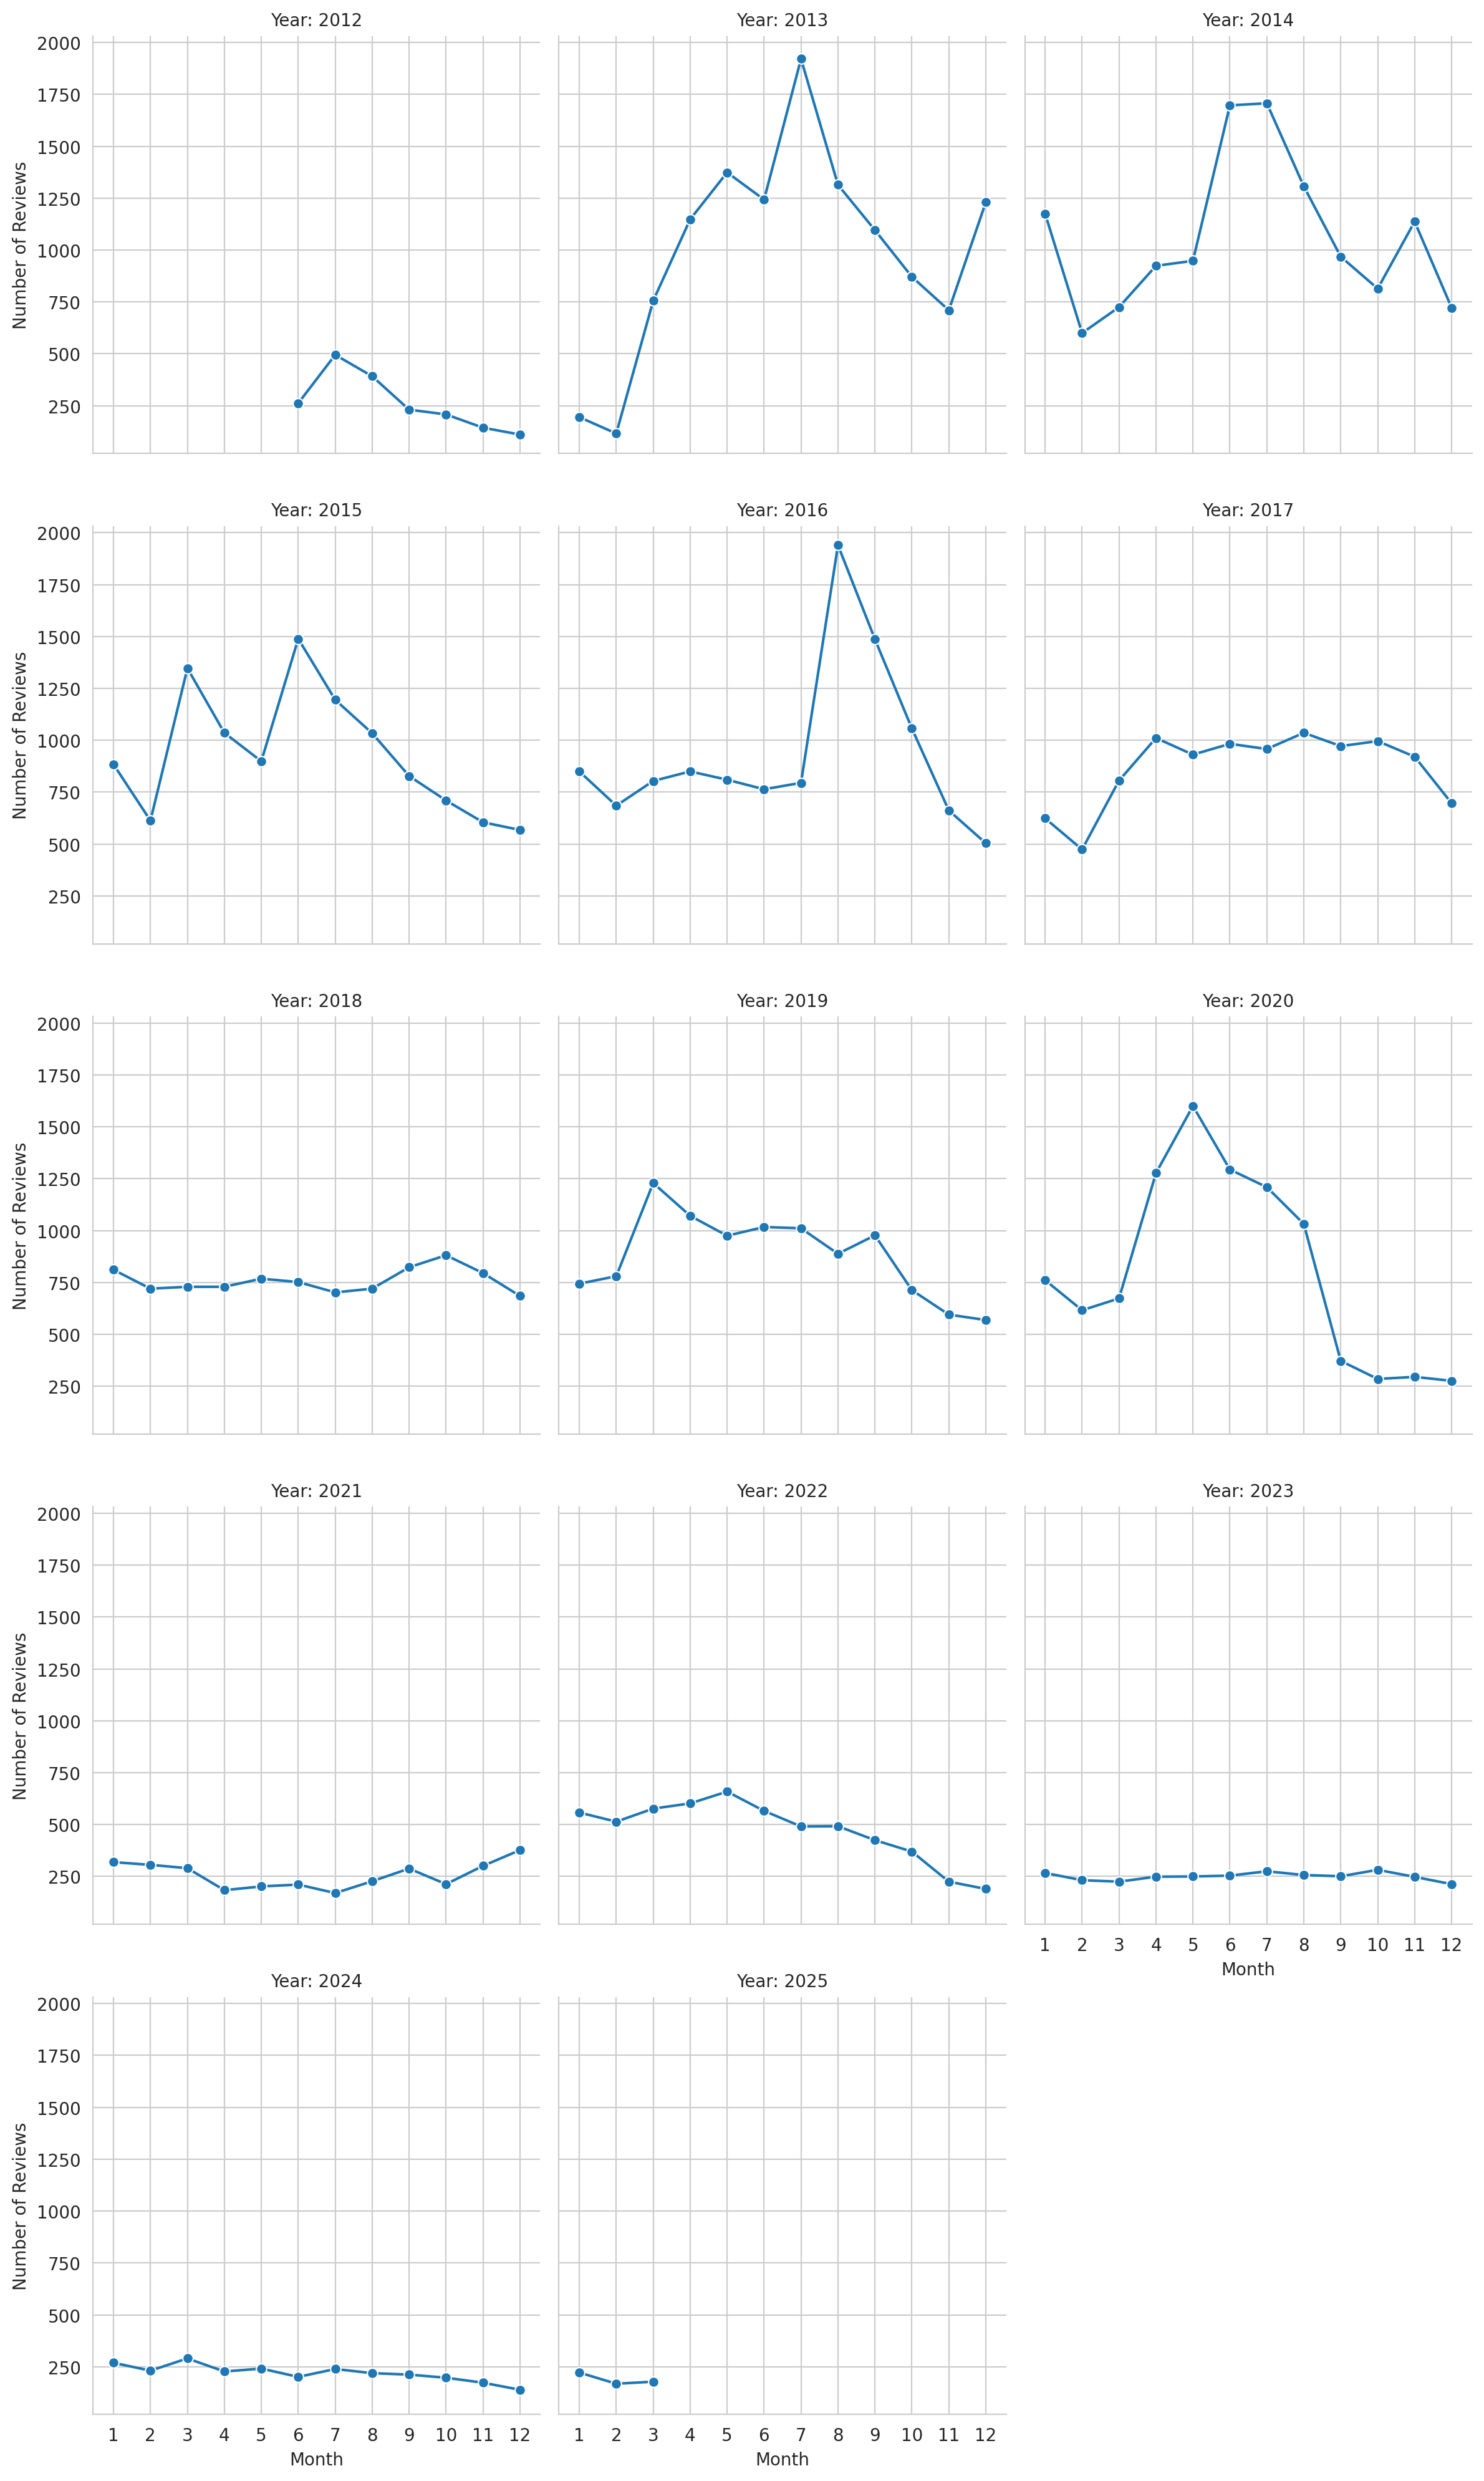

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ekstrak tahun dan bulan
df_nike_reviews2['year'] = df_nike_reviews2['at'].dt.year
df_nike_reviews2['month'] = df_nike_reviews2['at'].dt.month

# Group by year and month and count reviews
reviews_per_month = df_nike_reviews2.groupby(['year', 'month'])['id'].count().reset_index()

# Buat grid plot dengan FacetGrid
g = sns.FacetGrid(reviews_per_month, col='year', col_wrap=3, height=4, sharey=True)
g.map(sns.lineplot, 'month', 'id', marker='o')

# Tambahkan judul & label
g.set_axis_labels("Month", "Number of Reviews")
g.set_titles("Year: {col_name}")
plt.xticks(range(1, 13))  # Pastikan semua bulan muncul

plt.show()

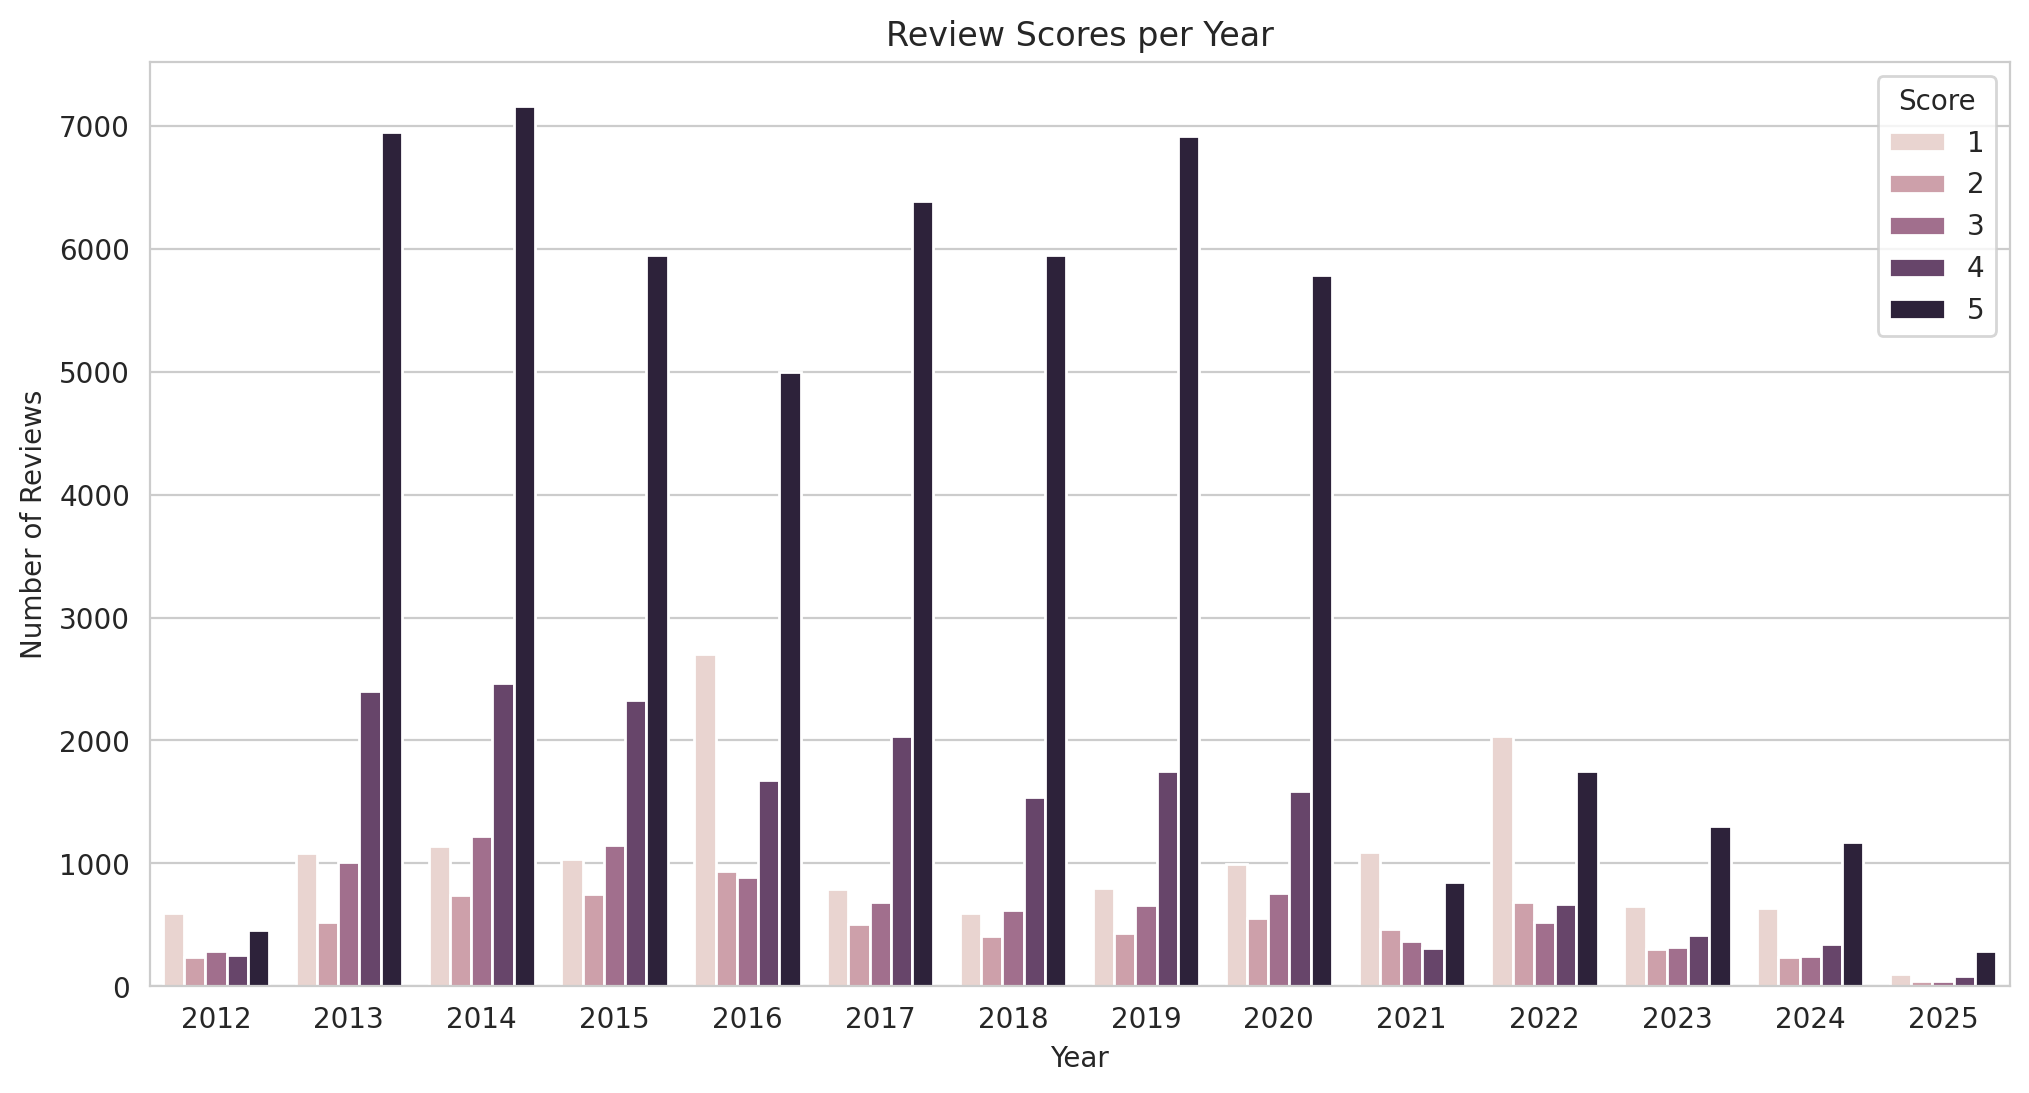

score,1,2,3,4,5
year,,,,,
2012,598,240,290,254,461
2013,1088,525,1009,2405,6947
2014,1139,744,1220,2465,7156
2015,1033,749,1151,2330,5945
2016,2702,940,891,1681,4994
2017,792,504,686,2039,6388
2018,595,412,619,1542,5947
2019,800,438,665,1754,6912
2020,994,556,758,1593,5789


In [112]:
score_per_year = df_nike_reviews2.groupby(['year', 'score'])['id'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='year', y='id', hue='score', data=score_per_year)
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Review Scores per Year')
plt.legend(title='Score')
plt.show()

score_per_year = df_nike_reviews2.groupby('year')['score'].value_counts().unstack(fill_value=0)
score_per_year


## Wordcloud

Frasa negatif dengan kata positif: {'without a great', 'without gas good', 'without a good'}


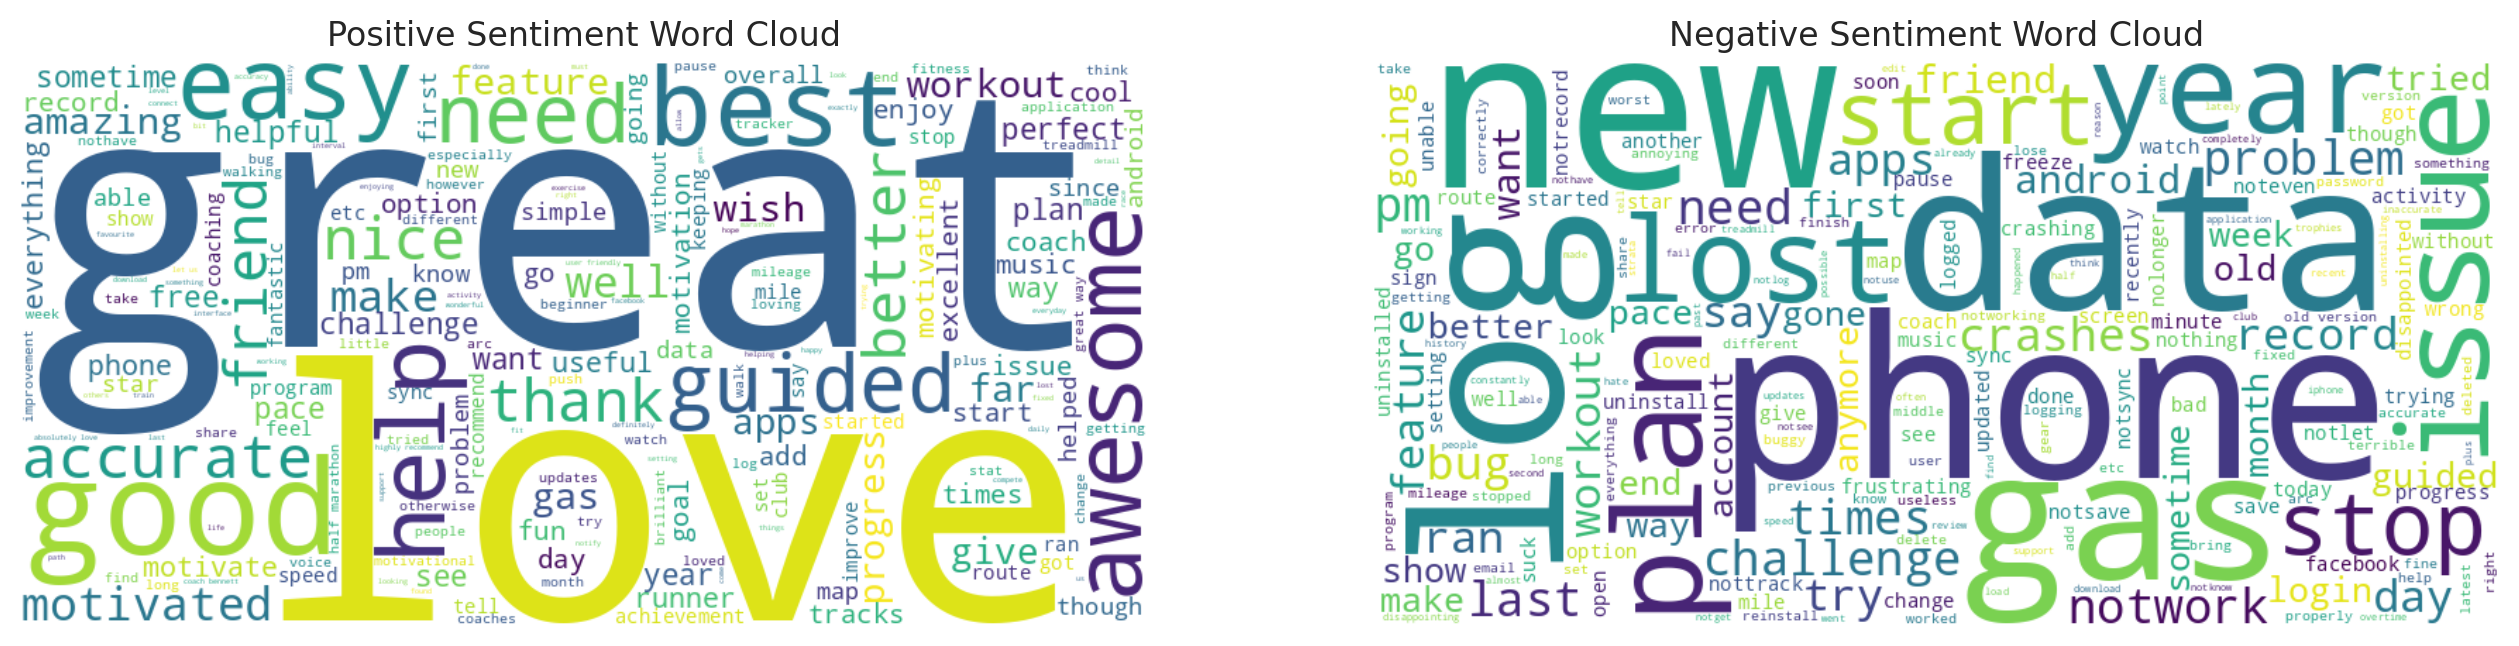

In [113]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Stopwords tambahan (kata-kata positif yang tidak ingin muncul di negatif)
positive_words = {'good', 'great', 'excellent', 'awesome', 'fantastic', 'amazing', 'best', 'nice', 'love', 'perfect'}

# Kata negatif umum yang sering muncul
negative_markers = {'not', 'never', 'barely', 'hardly', 'no', 'without'}

# Gabungkan stopwords tambahan dengan stopwords default WordCloud
all_stopwords = STOPWORDS.union(english_stopwords).union(positive_words)

# Pisahkan review positif dan negatif
positive_reviews = df_nike_reviews2[df_nike_reviews2['sentiment_rating'] == 'Positive']['final_cleaned']
negative_reviews = df_nike_reviews2[df_nike_reviews2['sentiment_rating'] == 'Negative']['final_cleaned']

# Deteksi frasa negatif kompleks (misal: "not really good", "not at all great")
frasa_negatif_kompleks = []
for review in negative_reviews:
    words = review.split()
    for i in range(len(words)):
        # Cek bi-gram (2 kata)
        if i < len(words) - 1 and words[i] in negative_markers and words[i + 1] in positive_words:
            frasa_negatif_kompleks.append(f"{words[i]} {words[i + 1]}")

        # Cek tri-gram (3 kata)
        if i < len(words) - 2 and words[i] in negative_markers and words[i + 2] in positive_words:
            frasa_negatif_kompleks.append(f"{words[i]} {words[i + 1]} {words[i + 2]}")

print("Frasa negatif dengan kata positif:", set(frasa_negatif_kompleks))

# Update stopwords dengan frasa negatif yang terdeteksi
all_stopwords = all_stopwords.union(set(frasa_negatif_kompleks))

# Buat WordCloud untuk sentimen positif dan negatif
positive_wordcloud = WordCloud(
    width=800, height=400, background_color='white', stopwords=english_stopwords
).generate(' '.join(positive_reviews))

negative_wordcloud = WordCloud(
    width=800, height=400, background_color='white', stopwords=all_stopwords
).generate(' '.join(negative_reviews))

# Tampilkan WordCloud untuk positif dan negatif
plt.figure(figsize=(16, 8))

# WordCloud Positif
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")

# WordCloud Negatif
plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")

plt.show()


In [114]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [115]:
df_nike_reviews2

,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,id,sentiment_polarity,sentiment_subjectivity,sentiment_rating,final_cleaned,token,token_after_sr,lemmatized_tokens,cleaned_text,year,month
1,the nike run club is the best the app tracks p...,5,0,4.64.0,2025-03-25 00:54:56,4.64.0,2,1.000000,0.300000,Positive,the nike run club is the best the app tracks p...,"[the, nike, run, club, is, the, best, the, app...","[club, best, tracks, progress, graphically, ge...","[club, best, track, progress, graphically, geo...",club best track progress graphically geographi...,2025,3
2,this app has various guided training options t...,5,0,4.64.0,2025-03-25 00:52:34,4.64.0,3,0.000000,0.500000,Positive,this app has various guided training options t...,"[this, app, has, various, guided, training, op...","[various, guided, options, help, runners, trai...","[various, guided, option, help, runner, train,...",various guided option help runner train goal w...,2025,3
3,i like everything the app has to offer from gu...,2,0,4.64.0,2025-03-25 00:42:15,4.64.0,4,0.000000,0.333333,Negative,i like everything the app has to offer from gu...,"[i, like, everything, the, app, has, to, offer...","[everything, offer, guidance, challenges, cons...","[everything, offer, guidance, challenge, const...",everything offer guidance challenge constantly...,2025,3
4,easy to use beginner friendly i am not a bot,5,0,4.64.0,2025-03-24 18:01:49,4.64.0,5,0.404167,0.666667,Positive,easy to use beginner friendly i am nota bot,"[easy, to, use, beginner, friendly, i, am, not...","[easy, beginner, friendly, nota, bot]","[easy, beginner, friendly, nota, bot]",easy beginner friendly nota bot,2025,3
5,i would not have run my first half maranthon g...,5,0,4.64.0,2025-03-24 14:45:33,4.64.0,6,0.045833,0.400000,Positive,i would nothave run my first half marathon goa...,"[i, would, nothave, run, my, first, half, mara...","[nothave, first, half, marathon, goal, without...","[nothave, first, half, marathon, goal, without...",nothave first half marathon goal without help ...,2025,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126511,i am really excited that this app has finally ...,4,2,1.0.0,2012-06-21 23:37:49,1.0.0,126512,0.222917,0.722222,Positive,i am really excited that this app has finally ...,"[i, am, really, excited, that, this, app, has,...","[excited, finally, shown, android, far, looks,...","[excited, finally, shown, android, far, look, ...",excited finally shown android far look great n...,2012,6
126513,great for anyone who starts running or training,5,0,NaN,2012-06-21 23:31:12,NaN,126514,0.800000,0.750000,Positive,great for anyone who starts running or training,"[great, for, anyone, who, starts, running, or,...","[great, anyone, starts]","[great, anyone, start]",great anyone start,2012,6
126514,this is soooo much better then the iphone app ...,5,1,NaN,2012-06-21 23:16:50,NaN,126515,0.626667,0.720000,Positive,this is soon much better then the iphone app g...,"[this, is, soon, much, better, then, the, ipho...","[soon, better, iphone, good, job, great, see, ...","[soon, better, iphone, good, job, great, see, ...",soon better iphone good job great see create g...,2012,6
126515,just completed my first run with this new app ...,5,6,1.0.0,2012-06-21 23:11:38,1.0.0,126516,0.357273,0.579004,Positive,just completed my first run with this new app ...,"[just, completed, my, first, run, with, this, ...","[completed, first, new, worked, great, nice, i...","[completed, first, new, worked, great, nice, i...",completed first new worked great nice integrat...,2012,6
